#  PRCP-1014: Vaccine Prediction using Machine Learning

## Project Overview

Vaccination is one of the most effective public health measures used to prevent infectious diseases and reduce their spread across communities. Understanding the factors that influence an individual's decision to receive a vaccine can help governments and healthcare organizations design better awareness campaigns and vaccination strategies.

In this project, we analyze data collected from the National 2009 H1N1 Flu Survey to identify the demographic, behavioral, social, and health-related factors associated with vaccine uptake.

The objective is to build predictive machine learning models capable of estimating whether an individual is likely to receive:

- H1N1 Influenza Vaccine
- Seasonal Influenza Vaccine

The project follows a complete Data Science workflow including data preprocessing, exploratory data analysis, feature engineering, model development, performance evaluation, model comparison, and business insights.

---

## Problem Statement

- Healthcare organizations often need to identify groups of people who are less likely to receive vaccinations. 
- Predicting vaccination acceptance helps policymakers develop awareness campaigns and allocate healthcare resources more effectively. 
- The objective is to build a classification model that predicts vaccine acceptance based on individual characteristics.

---

## Business Objective

The primary objective of this project is to develop a predictive machine learning solution that helps identify individuals who are less likely to receive vaccination.

Such predictions can assist healthcare organizations in:

- Improving vaccination awareness campaigns
- Identifying high-risk populations
- Increasing vaccination coverage
- Reducing disease transmission through herd immunity
- Supporting data-driven public health decision making


## Project Objectives

The main objectives of this project are:

- Study the characteristics of the dataset.
- Perform data cleaning and preprocessing.
- Handle missing values appropriately.
- Explore relationships among different variables.
- Build machine learning classification models.
- Compare model performance using evaluation metrics.
- Identify the model that produces reliable predictions.


# Future Scope

- Evaluate additional machine learning algorithms such as LightGBM and advanced CatBoost configurations.
- Apply feature selection techniques to improve efficiency and reduce model complexity.
- Explore explainable AI methods (e.g., SHAP) to better understand model predictions.
- Validate the model using external datasets to assess generalization.
- Develop a web application or dashboard for real-time vaccination prediction and visualization.


---

## Dataset Description

The dataset contains information collected through a public health survey. Each record represents an individual and includes demographic information, health conditions, behavioral habits, opinions regarding vaccines, and vaccination status.

The target variable indicates whether the individual received the H1N1 vaccine.

## Machine Learning Approach

This project follows a supervised machine learning approach using multiple classification algorithms.

The overall workflow includes:

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Model Comparison
10. Business Insights & Conclusion

---


# Executive Summary

This project focuses on analyzing vaccination-related data and developing a machine learning model to predict vaccination outcomes. The workflow includes data cleaning, exploratory data analysis (EDA), preprocessing, model building, hyperparameter tuning, cross-validation, and model comparison. Multiple machine learning algorithms were evaluated, and the best-performing model was selected based on comprehensive performance metrics. The project aims to support data-driven decision-making in public health by identifying patterns associated with vaccination behavior.


## Expected Outcome

The final outcome of this project is to identify the most accurate and reliable machine learning model capable of predicting vaccination behavior while providing meaningful business insights for future vaccination programs.

#  Import Required Libraries

## Why are libraries important?

Python libraries provide optimized, reusable functions for data manipulation, visualization, preprocessing, machine learning, and model evaluation. Instead of writing complex algorithms from scratch, we use these libraries to build reliable and efficient data science solutions.

### Libraries used in this project

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **Scikit-learn** – Machine learning algorithms and utilities
- **XGBoost** – Extreme Gradient Boosting
- **LightGBM** – Gradient Boosting Framework
- **CatBoost** – Gradient Boosting for categorical data
- **Warnings** – Ignore unnecessary warning messages for cleaner output

In [171]:
# Import Required Libraries

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

# Data Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Performance Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print(" All required libraries imported successfully.")

 All required libraries imported successfully.


# Load the Dataset

## Why do we need to load the dataset?

Before performing any analysis or building machine learning models, the dataset must be loaded into Python.

In this project, the data is provided in two separate CSV files:

- **features.csv** → Contains all the independent variables (input features).
- **labels.csv** → Contains the target variables (H1N1 and Seasonal Vaccine).

Since both datasets share a common column named **respondent_id**, they need to be merged into a single dataset before analysis.

---

## Why Merge the Datasets?

Machine learning models require both input features and target variables in the same dataset.

Merging the datasets ensures that every respondent's demographic, behavioral, and health information is correctly matched with their vaccination status.

This creates a unified dataset that will be used throughout the remaining stages of the project.

---

## Expected Outcome

After merging:

- Each row represents one respondent.
- All input features and target variables are available in one DataFrame.
- The merged dataset becomes the primary dataset for EDA, preprocessing, and model building.

In [172]:
# Load the Feature and Label Datasets

# Load feature dataset
features_df = pd.read_csv("features.csv")

# Load label dataset
labels_df = pd.read_csv("labels.csv")
print("Datasets loaded successfully.")

Datasets loaded successfully.


In [173]:
# Display First Five Records

print("Feature Dataset")
display(features_df.head())

print("\nLabel Dataset")
display(labels_df.head())

Feature Dataset


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb



Label Dataset


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [174]:
# Check Dataset Dimensions

print("Feature Dataset Shape :", features_df.shape)
print("Label Dataset Shape   :", labels_df.shape)

# Merge Feature and Label Datasets
vaccine_df = pd.merge(
    features_df,
    labels_df,
    on="respondent_id",
    how="inner"
)

print("Datasets merged successfully.")


Feature Dataset Shape : (26707, 36)
Label Dataset Shape   : (26707, 3)
Datasets merged successfully.


In [175]:
# Verify the Merged Dataset

print("Merged Dataset Shape :", vaccine_df.shape)
display(vaccine_df.head())

Merged Dataset Shape : (26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [176]:
# Verify Dataset Information
print(f"Total Features Dataset Records : {features_df.shape[0]}")
print(f"Total Labels Dataset Records   : {labels_df.shape[0]}")
print(f"Merged Dataset Records         : {vaccine_df.shape[0]}")

if (
    vaccine_df.shape[0] == features_df.shape[0]
    and vaccine_df.shape[0] == labels_df.shape[0]
):
    print("\n Merge completed successfully without losing any records.")
else:
    print("\n Please verify the merge process.")

Total Features Dataset Records : 26707
Total Labels Dataset Records   : 26707
Merged Dataset Records         : 26707

 Merge completed successfully without losing any records.


In [177]:
# Create a Working Copy of the Dataset
df = vaccine_df.copy()
print("Working dataset created successfully.")

# why
# vaccine_df remains as the original merged dataset.
# df becomes the working dataset where all cleaning, preprocessing, and feature engineering are performed.
# If you make a mistake during preprocessing, you still have the original merged data.

Working dataset created successfully.


# Data Understanding

## Why is Data Understanding Important?

Before performing data cleaning, feature engineering, or model building, it is essential to understand the dataset thoroughly.

A proper understanding of the data helps us:

- Identify the number of observations and features.
- Understand the data types of each feature.
- Detect missing values.
- Identify duplicate records.
- Analyze numerical and categorical variables.
- Detect possible data quality issues.
- Decide appropriate preprocessing techniques.

Data understanding is one of the most important phases in the Data Science lifecycle because every decision made during preprocessing depends on the insights obtained in this stage.

---

## Objectives

In this section, we will:

- Examine the dataset structure.
- Understand feature data types.
- Analyze missing values.
- Check duplicate records.
- Generate descriptive statistics.
- Identify numerical and categorical features.
- Examine unique values.
- Calculate memory usage.
- Record initial observations.

In [178]:
# Dataset Dimensions
print("Dataset Dimensions")

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Dataset Dimensions
Number of Rows    : 26707
Number of Columns : 38


In [179]:
# Display Sample Records

print("First Five Records")
display(df.head())

print("\nLast Five Records")
display(df.tail())

First Five Records


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0



Last Five Records


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0
26706,26706,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,65+ Years,Some College,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,0.0,NaN,NaN,0,0


In [180]:
# Dataset Information
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 

In [181]:
# Statistical Summary
display(df.describe())

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,24547.000000,25736.000000,25887.000000,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,0.329735,0.283261,0.082590,0.111918,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,0.470126,0.450591,0.275266,0.315271,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


### Why use `describe()`?

The `describe()` function provides summary statistics for numerical variables, including:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Quartiles (25%, 50%, 75%)
- Maximum Value

These statistics help identify unusual values, skewness, and potential outliers.

In [182]:
# Summary of Categorical Variables
display(df.describe(include="object"))

,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation
count,26707,25300,26707,26707,22284,25299,24665,25244,26707,26707,13377,13237
unique,5,4,4,2,3,2,2,3,10,3,21,23
top,65+ Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",fcxhlnwr,xtkaffoo
freq,6843,10097,21222,15858,12777,13555,18736,13560,4297,11645,2468,1778


In [183]:
# Data Type Distribution

datatype_summary = (
    df.dtypes
      .value_counts()
      .rename_axis("Data Type")
      .reset_index(name="Count")
)

display(datatype_summary)

,Data Type,Count
0,float64,23
1,object,12
2,int64,3


In [184]:
# Separate Numerical and Categorical Features

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

Numerical Features   : 26
Categorical Features : 12


In [185]:
# Numerical Features

print("Numerical Columns")
for column in numerical_columns:
    print(f"• {column}")

Numerical Columns
• respondent_id
• h1n1_concern
• h1n1_knowledge
• behavioral_antiviral_meds
• behavioral_avoidance
• behavioral_face_mask
• behavioral_wash_hands
• behavioral_large_gatherings
• behavioral_outside_home
• behavioral_touch_face
• doctor_recc_h1n1
• doctor_recc_seasonal
• chronic_med_condition
• child_under_6_months
• health_worker
• health_insurance
• opinion_h1n1_vacc_effective
• opinion_h1n1_risk
• opinion_h1n1_sick_from_vacc
• opinion_seas_vacc_effective
• opinion_seas_risk
• opinion_seas_sick_from_vacc
• household_adults
• household_children
• h1n1_vaccine
• seasonal_vaccine


In [188]:
# Categorical Features

print("Categorical Columns")
for column in categorical_columns:
    print(f"• {column}")

Categorical Columns
• age_group
• education
• race
• sex
• income_poverty
• marital_status
• rent_or_own
• employment_status
• hhs_geo_region
• census_msa
• employment_industry
• employment_occupation


In [189]:
# Memory Usage

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Dataset Memory Usage : {memory_usage:.2f} MB")

Dataset Memory Usage : 22.40 MB


In [190]:
# Duplicate Record Analysis

duplicate_records = df.duplicated().sum()
print(f"Total Duplicate Records : {duplicate_records}")

Total Duplicate Records : 0


In [191]:
# Unique Values in Each Feature

unique_values = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique().values
})

display(unique_values)

,Feature,Data Type,Unique Values
respondent_id,respondent_id,int64,26707
h1n1_concern,h1n1_concern,float64,4
h1n1_knowledge,h1n1_knowledge,float64,3
behavioral_antiviral_meds,behavioral_antiviral_meds,float64,2
behavioral_avoidance,behavioral_avoidance,float64,2
behavioral_face_mask,behavioral_face_mask,float64,2
behavioral_wash_hands,behavioral_wash_hands,float64,2
behavioral_large_gatherings,behavioral_large_gatherings,float64,2
behavioral_outside_home,behavioral_outside_home,float64,2
behavioral_touch_face,behavioral_touch_face,float64,2


#  Initial Observations

After performing the initial inspection of the dataset, the following observations were made:

- The dataset contains **_____ rows** and **_____ columns**.
- The dataset includes both numerical and categorical features.
- Some features contain missing values and require preprocessing.
- No duplicate records were observed (or mention the actual count).
- The target variables are binary classification variables.
- Several categorical variables will require encoding before model training.
- Some numerical variables may require scaling depending on the machine learning algorithm.

These observations will guide the data cleaning and preprocessing steps in the next section.

# Data Quality Assessment

## Why is Data Quality Assessment Important?

The performance of any machine learning model heavily depends on the quality of the input data.

Poor-quality data can lead to:

- Incorrect predictions
- Biased models
- Reduced model performance
- Misleading business insights

Therefore, before performing data preprocessing, it is essential to evaluate the overall quality of the dataset.

---

## Objectives

In this section, we will:

- Analyze missing values.
- Calculate missing value percentages.
- Identify duplicate records.
- Detect constant features.
- Identify low-cardinality and high-cardinality features.
- Verify target variable distribution.
- Perform an overall data quality assessment.

The insights gathered in this section will help us choose appropriate preprocessing techniques for the next stage.

In [192]:
# Missing Value Summary

missing_summary = pd.DataFrame({

    "Feature": df.columns,

    "Missing Values": df.isnull().sum(),

    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)

})

missing_summary = (

    missing_summary

    .sort_values(

        by="Missing Percentage",

        ascending=False

    )

)

display(missing_summary)

,Feature,Missing Values,Missing Percentage
employment_occupation,employment_occupation,13470,50.44
employment_industry,employment_industry,13330,49.91
health_insurance,health_insurance,12274,45.96
income_poverty,income_poverty,4423,16.56
doctor_recc_h1n1,doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,doctor_recc_seasonal,2160,8.09
rent_or_own,rent_or_own,2042,7.65
employment_status,employment_status,1463,5.48
marital_status,marital_status,1408,5.27
education,education,1407,5.27


In [193]:
# Features Containing Missing Values

missing_features = missing_summary[missing_summary["Missing Values"] > 0]
print(f"Features with Missing Values : {missing_features.shape[0]}")
display(missing_features)

Features with Missing Values : 30


,Feature,Missing Values,Missing Percentage
employment_occupation,employment_occupation,13470,50.44
employment_industry,employment_industry,13330,49.91
health_insurance,health_insurance,12274,45.96
income_poverty,income_poverty,4423,16.56
doctor_recc_h1n1,doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,doctor_recc_seasonal,2160,8.09
rent_or_own,rent_or_own,2042,7.65
employment_status,employment_status,1463,5.48
marital_status,marital_status,1408,5.27
education,education,1407,5.27


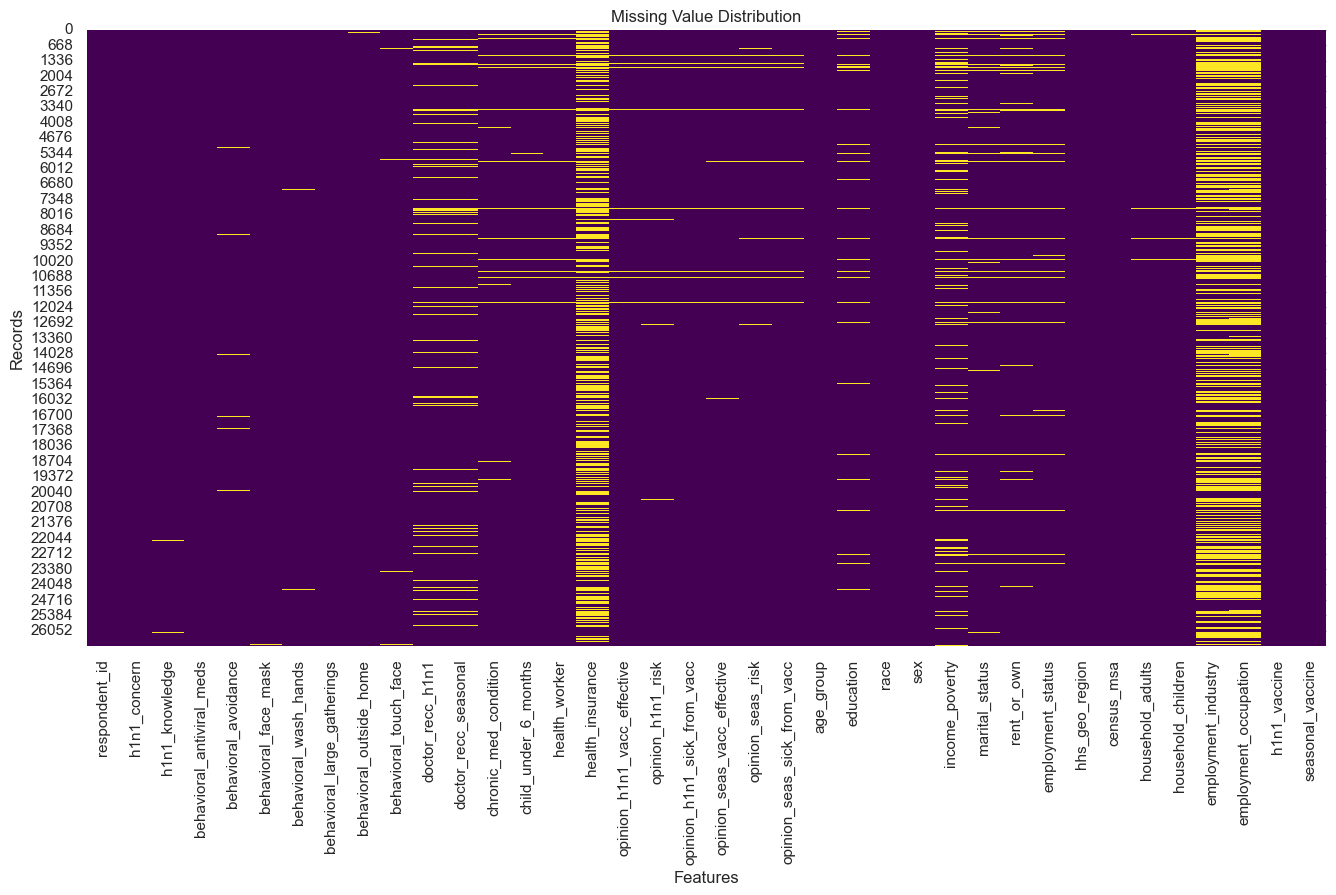

In [194]:
# Missing Value Heatmap

plt.figure(figsize=(16,8))

sns.heatmap(

    df.isnull(),

    cbar=False,

    cmap="viridis"

)

plt.title("Missing Value Distribution")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

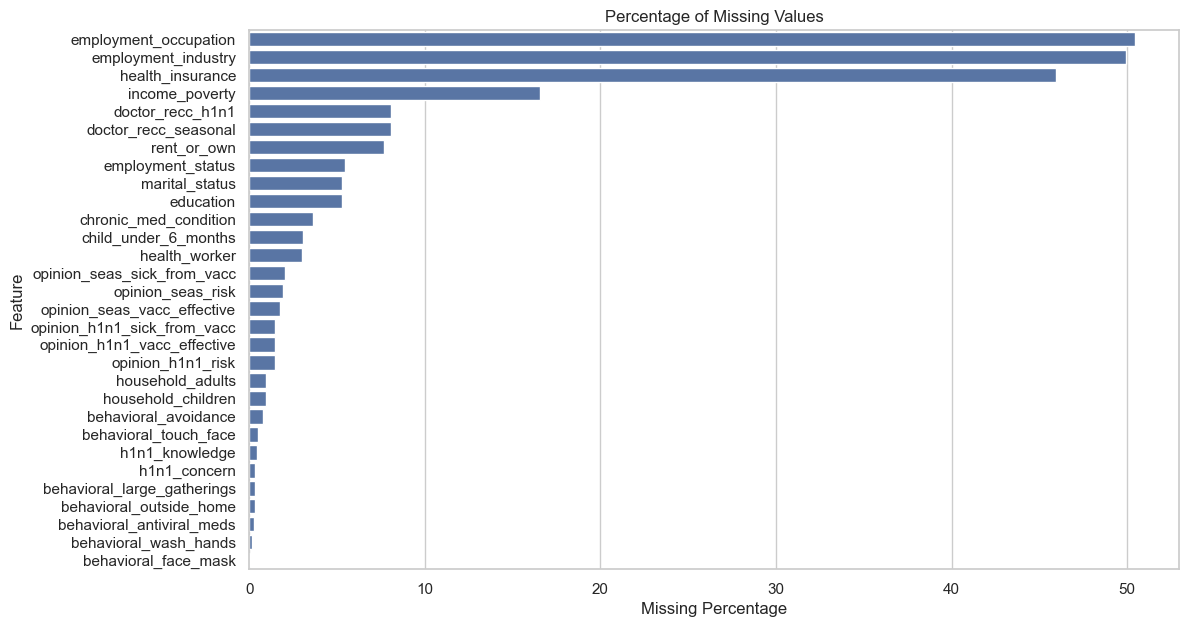

In [195]:
# Missing Value Percentage

missing_plot = missing_summary[missing_summary["Missing Percentage"] > 0]
plt.figure(figsize=(12,7))
sns.barplot(

    data=missing_plot,

    x="Missing Percentage",

    y="Feature"

)

plt.title("Percentage of Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

In [196]:
# Duplicate Record Analysis

duplicate_records = df.duplicated().sum()
print(f"Duplicate Records : {duplicate_records}")

Duplicate Records : 0


In [198]:
# Identify Constant Features

constant_features = [
    column
    for column in df.columns
    if df[column].nunique() == 1
]

print(f"Constant Features : {len(constant_features)}")
constant_features

Constant Features : 0


[]

In [200]:
# Low Cardinality Features

low_cardinality = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": df.nunique()
})

low_cardinality = low_cardinality.sort_values(
    by="Unique Values"
)
display(low_cardinality)

,Feature,Unique Values
seasonal_vaccine,seasonal_vaccine,2
marital_status,marital_status,2
rent_or_own,rent_or_own,2
h1n1_vaccine,h1n1_vaccine,2
health_insurance,health_insurance,2
health_worker,health_worker,2
sex,sex,2
chronic_med_condition,chronic_med_condition,2
doctor_recc_seasonal,doctor_recc_seasonal,2
doctor_recc_h1n1,doctor_recc_h1n1,2


In [28]:
# High Cardinality Features

high_cardinality = low_cardinality[low_cardinality["Unique Values"] > 20]
display(high_cardinality)

,Feature,Unique Values
employment_industry,employment_industry,21
employment_occupation,employment_occupation,23
respondent_id,respondent_id,26707


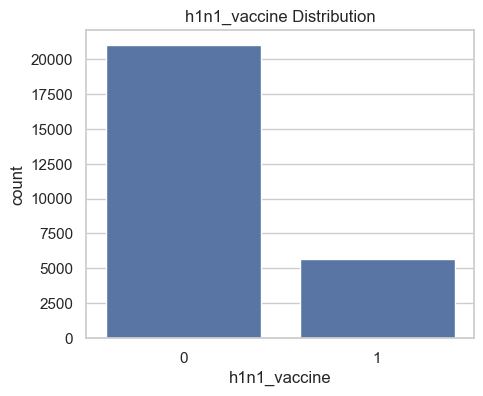

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64


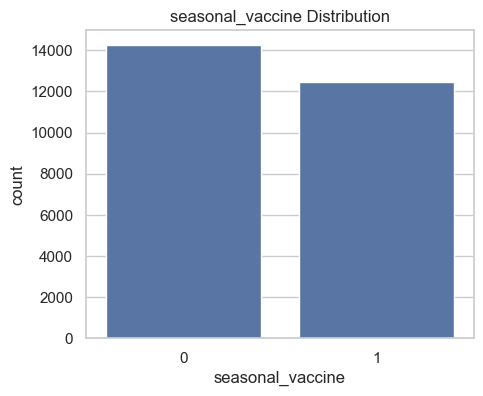

seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


In [202]:
# Target Variable Distribution

target_columns = ["h1n1_vaccine","seasonal_vaccine"]
for target in target_columns:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df,x=target)
    plt.title(f"{target} Distribution")
    plt.show()
    print(df[target].value_counts())

#  Data Quality Observations

The following observations were made after assessing the dataset quality:

- Several features contain missing values.
- Missing values are concentrated in specific categorical variables.
- No (or few) duplicate records are present.
- The dataset contains binary, ordinal, and nominal categorical features.
- No constant features were found (or mention if any exist).
- The target variable distribution indicates whether the dataset is balanced or imbalanced.
- Appropriate imputation and encoding techniques will be applied in the next stage.

These findings provide a clear roadmap for data preprocessing and feature engineering.

#  Data Cleaning & Preprocessing

## Why is Data Cleaning Important?

Raw data collected from surveys often contains missing values, inconsistent formats, duplicate records, and irrelevant features. Machine learning algorithms cannot effectively learn from poor-quality data.

Data cleaning improves:

- Data quality
- Model accuracy
- Model reliability
- Business insights
- Overall prediction performance

In this section, we will prepare the dataset for machine learning by handling missing values, removing unnecessary features, and preserving useful information.

---

## Preprocessing Strategy

The following preprocessing steps will be performed:

- Remove unnecessary features.
- Handle missing values.
- Preserve ordinal information.
- Prepare categorical variables for encoding.
- Verify the cleaned dataset before Exploratory Data Analysis.

Each preprocessing decision is made based on the characteristics of the dataset rather than applying generic techniques.

In [203]:
# Remove Respondent Identifier

# respondent_id is a unique identifier and does not contribute
# to predicting vaccination behavior.

df.drop(columns="respondent_id", inplace=True)
print("respondent_id has been removed successfully.")

respondent_id has been removed successfully.


### Why was `respondent_id` removed?

The `respondent_id` column is a unique identifier assigned to each survey participant.

Since it does not contain any meaningful information related to vaccination behavior, it does not contribute to the prediction process.

Removing such identifier columns helps reduce unnecessary complexity and prevents the model from learning irrelevant patterns.

In [204]:
# Missing Value Summary After Removing Identifier

missing_summary = (df.isnull().sum().to_frame(name="Missing Values"))
missing_summary["Missing Percentage"] = (missing_summary["Missing Values"]/ len(df)* 100).round(2)
missing_summary = (missing_summary.sort_values(by="Missing Percentage",ascending=False))

display(missing_summary)

,Missing Values,Missing Percentage
employment_occupation,13470,50.44
employment_industry,13330,49.91
health_insurance,12274,45.96
income_poverty,4423,16.56
doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,2160,8.09
rent_or_own,2042,7.65
employment_status,1463,5.48
marital_status,1408,5.27
education,1407,5.27


In [205]:
# Categorize Features Based on Data Type

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 25
Categorical Features : 12


## Why separate numerical and categorical features?

Different feature types require different preprocessing techniques.

### Numerical Features

Numerical variables are generally imputed using:

- Mean
- Median

depending on their distribution.

---

### Categorical Features

Categorical variables are commonly imputed using:

- Mode (Most Frequent Value)

because replacing missing values with the most common category preserves the existing data distribution.

In [206]:
# Features Containing Missing Values

missing_columns = [
    column
    for column in df.columns
    if df[column].isnull().sum() > 0
]

print("Columns with Missing Values:\n")
for column in missing_columns:
    print(f"{column:<30} {df[column].isnull().sum():>6}")

Columns with Missing Values:

h1n1_concern                       92
h1n1_knowledge                    116
behavioral_antiviral_meds          71
behavioral_avoidance              208
behavioral_face_mask               19
behavioral_wash_hands              42
behavioral_large_gatherings        87
behavioral_outside_home            82
behavioral_touch_face             128
doctor_recc_h1n1                 2160
doctor_recc_seasonal             2160
chronic_med_condition             971
child_under_6_months              820
health_worker                     804
health_insurance                12274
opinion_h1n1_vacc_effective       391
opinion_h1n1_risk                 388
opinion_h1n1_sick_from_vacc       395
opinion_seas_vacc_effective       462
opinion_seas_risk                 514
opinion_seas_sick_from_vacc       537
education                        1407
income_poverty                   4423
marital_status                   1408
rent_or_own                      2042
employment_status   

In [207]:
df.fillna(df.mode())

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,fcxhlnwr,xtkaffoo,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


#  Missing Value Treatment Strategy

## Why do we need a Missing Value Strategy?

Missing values are common in real-world datasets, especially in survey-based data. Simply removing rows or replacing all missing values with the same technique may lead to loss of information or introduce bias.

Therefore, before performing imputation, we analyze:

- The number of missing values.
- The percentage of missing values.
- The data type of each feature.
- The business meaning of the feature.

Based on these observations, an appropriate imputation strategy is selected for every feature.

---

## Common Imputation Techniques

### Mean Imputation
Used for normally distributed numerical variables.

### Median Imputation
Used for skewed numerical variables because it is less affected by outliers.

### Mode Imputation
Used for binary and categorical variables.

### Unknown Category
Used for categorical features with a high percentage of missing values where missing itself may carry useful information.

Our objective is to preserve as much information as possible while minimizing data distortion.

In [208]:
# Create Missing Value Report

missing_report = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})
missing_report = missing_report.sort_values(by="Missing Percentage",ascending=False)
display(missing_report)

,Feature,Data Type,Missing Values,Missing Percentage
employment_occupation,employment_occupation,object,13470,50.44
employment_industry,employment_industry,object,13330,49.91
health_insurance,health_insurance,float64,12274,45.96
income_poverty,income_poverty,object,4423,16.56
doctor_recc_h1n1,doctor_recc_h1n1,float64,2160,8.09
doctor_recc_seasonal,doctor_recc_seasonal,float64,2160,8.09
rent_or_own,rent_or_own,object,2042,7.65
employment_status,employment_status,object,1463,5.48
marital_status,marital_status,object,1408,5.27
education,education,object,1407,5.27


In [209]:
# Suggest Imputation Method Based on Data Type

preprocessing_plan = missing_report.copy()
def suggest_imputation(row):

    if row["Missing Values"] == 0:
        return "No Action Required"

    if row["Data Type"] == "object":
        return "Mode / Unknown Category"

    return "Median / Mode"

preprocessing_plan["Suggested Method"] = preprocessing_plan.apply(suggest_imputation,axis=1)
display(preprocessing_plan)

,Feature,Data Type,Missing Values,Missing Percentage,Suggested Method
employment_occupation,employment_occupation,object,13470,50.44,Mode / Unknown Category
employment_industry,employment_industry,object,13330,49.91,Mode / Unknown Category
health_insurance,health_insurance,float64,12274,45.96,Median / Mode
income_poverty,income_poverty,object,4423,16.56,Mode / Unknown Category
doctor_recc_h1n1,doctor_recc_h1n1,float64,2160,8.09,Median / Mode
doctor_recc_seasonal,doctor_recc_seasonal,float64,2160,8.09,Median / Mode
rent_or_own,rent_or_own,object,2042,7.65,Mode / Unknown Category
employment_status,employment_status,object,1463,5.48,Mode / Unknown Category
marital_status,marital_status,object,1408,5.27,Mode / Unknown Category
education,education,object,1407,5.27,Mode / Unknown Category


In [210]:
df.fillna(df.mode())

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,fcxhlnwr,xtkaffoo,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


## Preprocessing Decision

Based on the missing value assessment, the following strategy will be adopted:

- Binary categorical variables → Mode Imputation
- Ordinal categorical variables → Mode Imputation
- Nominal categorical variables with large missing percentages → "Unknown" Category
- Numerical variables (if any contain missing values) → Median Imputation

This approach preserves valuable information while minimizing bias introduced during preprocessing.

In [212]:
# Fill Missing Values in Binary and Ordinal Features

mode_imputation_columns = [

    "h1n1_concern",
    "h1n1_knowledge",
    "behavioral_antiviral_meds",
    "behavioral_avoidance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
    "behavioral_large_gatherings",
    "behavioral_outside_home",
    "behavioral_touch_face",
    "doctor_recc_h1n1",
    "doctor_recc_seasonal",
    "chronic_med_condition",
    "child_under_6_months",
    "health_worker",
    "health_insurance",
    "opinion_h1n1_vacc_effective",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    "opinion_seas_vacc_effective",
    "opinion_seas_risk",
    "opinion_seas_sick_from_vacc",
    "age_group",
    "education",
    "race",
    "sex",
    "income_poverty",
    "marital_status",
    "rent_or_own",
    "employment_status",
    "hhs_geo_region",
    "census_msa"
]

for column in mode_imputation_columns:

    if df[column].isnull().sum() > 0:
        df[column].fillna(
            df[column].mode()[0],
            inplace=True
        )

print("Mode imputation completed successfully.")

Mode imputation completed successfully.


In [213]:
# Replace Missing Categories with 'Unknown'

unknown_category_columns = ["employment_industry","employment_occupation"]
for column in unknown_category_columns:
    df[column].fillna("Unknown",inplace=True)

print("High missing categorical features handled successfully.")

High missing categorical features handled successfully.


In [214]:
# Verify Missing Values After Imputation

remaining_missing = df.isnull().sum().sum()
print(f"Remaining Missing Values : {remaining_missing}")

Remaining Missing Values : 498


In [215]:
# Check Remaining Missing Values

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
display(remaining_missing)

household_adults      249
household_children    249
dtype: int64

In [216]:
# Verify Missing Values by Feature

for column in df.columns:
    missing_count = df[column].isnull().sum()
    if missing_count > 0:
        print(f"{column:<30} {missing_count}")

household_adults               249
household_children             249


#  Final Data Quality Verification

## Why do we verify the cleaned dataset?

Data preprocessing should always be followed by a verification step to ensure that all identified data quality issues have been resolved successfully.

This verification helps us confirm:

- Missing values have been handled appropriately.
- Duplicate records have been removed or validated.
- The dataset is now ready for Exploratory Data Analysis (EDA).
- Machine learning models will receive clean and consistent input data.

Performing this validation minimizes the risk of unexpected errors during later stages of the project.

In [217]:
# Final Missing Value Summary

final_missing = pd.DataFrame({"Feature": df.columns,"Missing Values": df.isnull().sum()})
final_missing = final_missing[final_missing["Missing Values"] > 0]
if final_missing.empty:
    print(" No missing values found in the dataset.")

else:
    print(" Remaining Missing Values")
    display(final_missing)

 Remaining Missing Values


,Feature,Missing Values
household_adults,household_adults,249
household_children,household_children,249


In [218]:
# Duplicate Record Verification

duplicate_records = df.duplicated().sum()
print(f"Duplicate Records : {duplicate_records}")

Duplicate Records : 1


In [219]:
# Dataset Overview After Cleaning

print("Dataset Shape")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()
print("Data Types")
display(df.dtypes.value_counts())

Dataset Shape
Rows    : 26707
Columns : 37

Data Types


float64    23
object     12
int64       2
Name: count, dtype: int64

#  Data Cleaning Summary

The dataset has now undergone the initial preprocessing stage.

The following preprocessing activities have been completed:

- Removed unnecessary identifier columns.
- Handled missing values using suitable imputation techniques.
- Preserved useful categorical information.
- Verified duplicate records.
- Confirmed the overall dataset structure.

The cleaned dataset is now ready for Exploratory Data Analysis (EDA), where we will investigate feature distributions, identify important patterns, and derive meaningful business insights.

#  Exploratory Data Analysis (EDA)

## What is Exploratory Data Analysis?

Exploratory Data Analysis (EDA) is the process of examining the dataset to understand its characteristics, identify hidden patterns, detect anomalies, and discover relationships between variables before building machine learning models.

EDA helps transform raw data into meaningful business insights and supports informed decisions during feature engineering and model development.

---

## Objectives of EDA

In this section, we will:

- Analyze the distribution of target variables.
- Understand demographic characteristics of respondents.
- Study behavioral and health-related factors.
- Explore public opinions regarding vaccines.
- Identify relationships between features and vaccination status.
- Generate meaningful business insights.

The findings from EDA will guide feature selection and improve model performance.

In [220]:
# Configure Visualization Settings

# Set Seaborn theme
sns.set_theme(
    style="whitegrid",
    palette="Set2"
)

# Default figure size
plt.rcParams["figure.figsize"] = (10, 6)

# Font sizes
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

print("Visualization settings configured successfully.")

Visualization settings configured successfully.


#  Target Variable Analysis

## Why analyze the target variable first?

The target variable is the variable that the machine learning model will predict.

Understanding its distribution helps us:

- Detect class imbalance.
- Choose suitable evaluation metrics.
- Decide whether resampling techniques such as SMOTE are required.
- Understand the overall vaccination trends.

The project contains two target variables:

- H1N1 Vaccine
- Seasonal Flu Vaccine

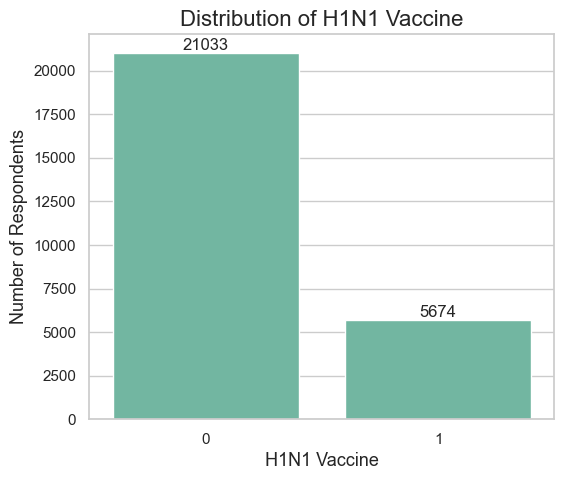

In [221]:
# Distribution of H1N1 Vaccine

plt.figure(figsize=(6,5))
ax = sns.countplot(
    data=df,
    x="h1n1_vaccine"
)

plt.title("Distribution of H1N1 Vaccine")
plt.xlabel("H1N1 Vaccine")
plt.ylabel("Number of Respondents")

# Display count labels
for container in ax.containers:
    ax.bar_label(container)
plt.show()

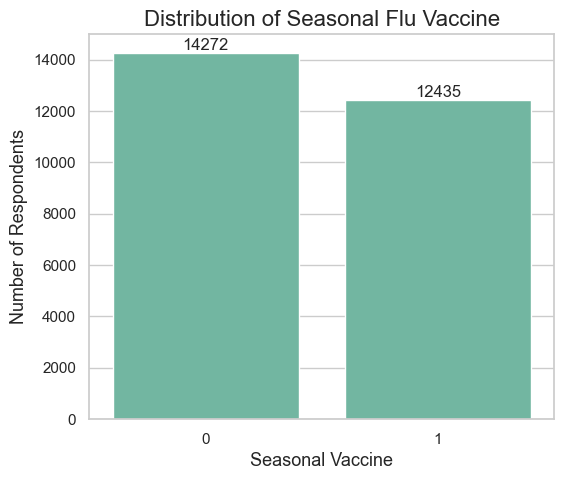

In [222]:
# Distribution of Seasonal Vaccine

plt.figure(figsize=(6,5))
ax = sns.countplot(
    data=df,
    x="seasonal_vaccine"
)
plt.title("Distribution of Seasonal Flu Vaccine")
plt.xlabel("Seasonal Vaccine")
plt.ylabel("Number of Respondents")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

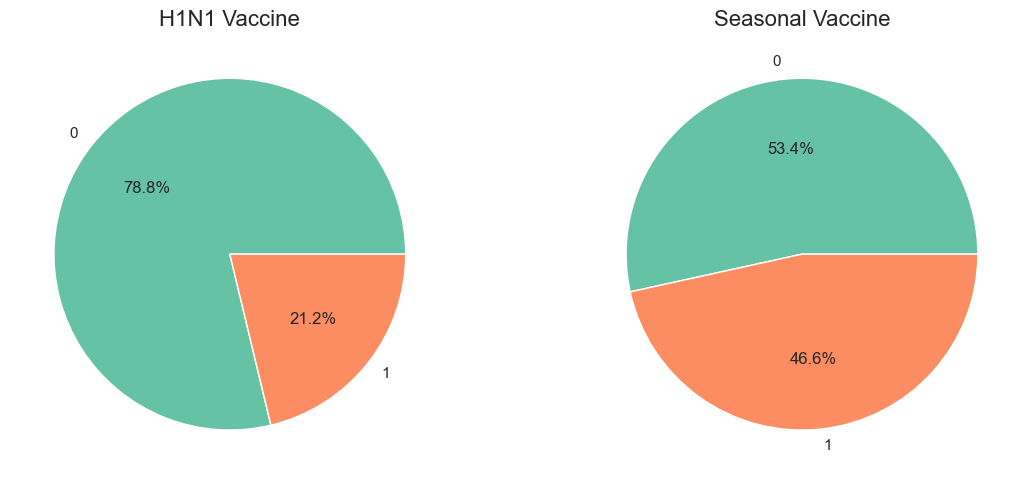

In [223]:
# Percentage Distribution of Target Variables

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# H1N1 Vaccine
df["h1n1_vaccine"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0]
)
axes[0].set_title("H1N1 Vaccine")
axes[0].set_ylabel("")


# Seasonal Vaccine
df["seasonal_vaccine"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)
axes[1].set_title("Seasonal Vaccine")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

# Demographic Analysis

## Why analyze demographic features?

Demographic characteristics provide valuable insights into vaccination behavior across different population groups.

Understanding these characteristics helps answer questions such as:

- Which age group has the highest vaccination rate?
- Does gender influence vaccination decisions?
- Does education improve vaccine acceptance?
- Does income affect vaccination behavior?
- Which demographic groups require greater awareness campaigns?

These insights are useful for both public health policy and machine learning feature selection.

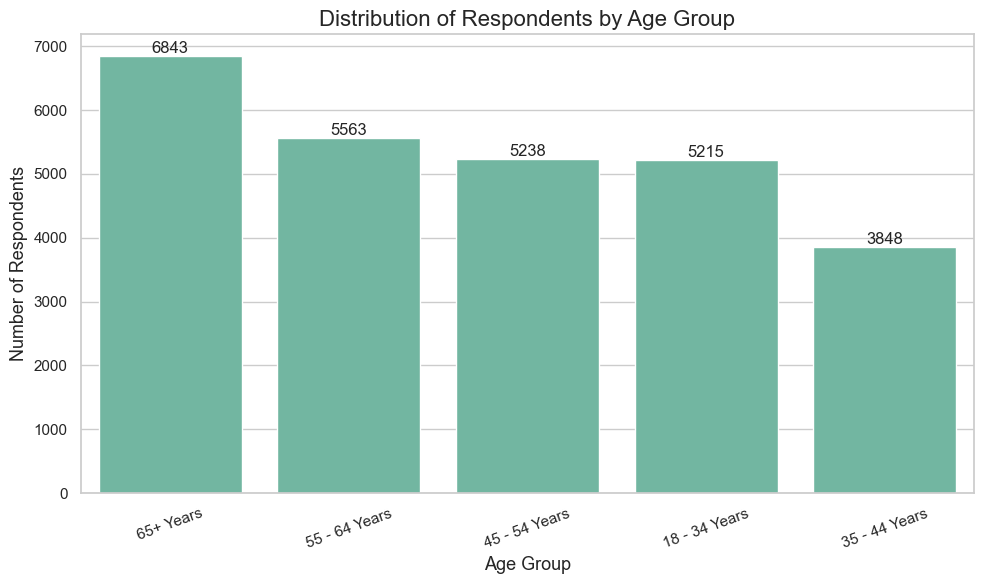

In [224]:
# Age Group Distribution

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="age_group",
    order=df["age_group"].value_counts().index
)

plt.title("Distribution of Respondents by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)
    
plt.tight_layout()
plt.show()

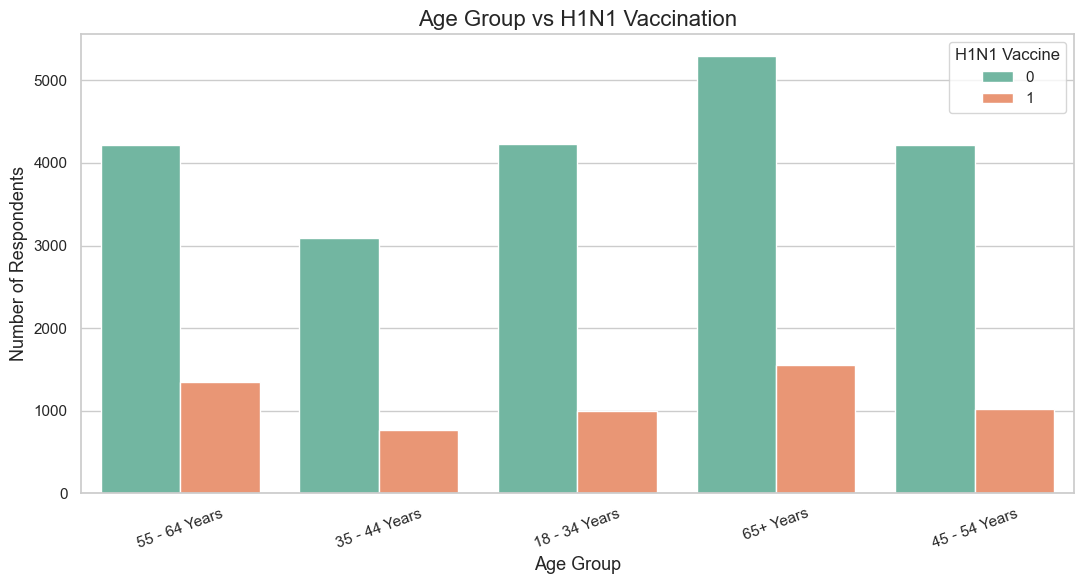

In [225]:
# Age Group vs H1N1 Vaccine

plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    x="age_group",
    hue="h1n1_vaccine"
)

plt.title("Age Group vs H1N1 Vaccination")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.legend(title="H1N1 Vaccine")
plt.tight_layout()
plt.show()

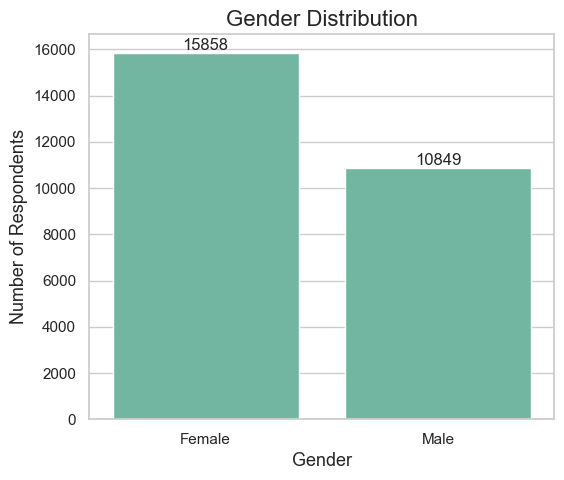

In [226]:
# Gender Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="sex"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

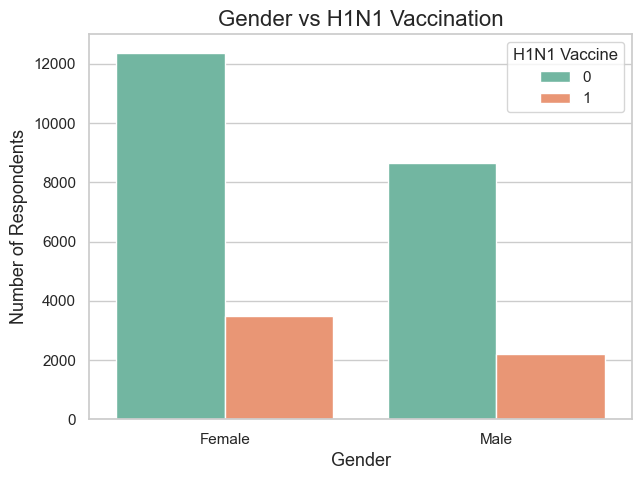

In [227]:
# Gender vs H1N1 Vaccine

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sex",
    hue="h1n1_vaccine"
)

plt.title("Gender vs H1N1 Vaccination")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")
plt.legend(title="H1N1 Vaccine")
plt.show()

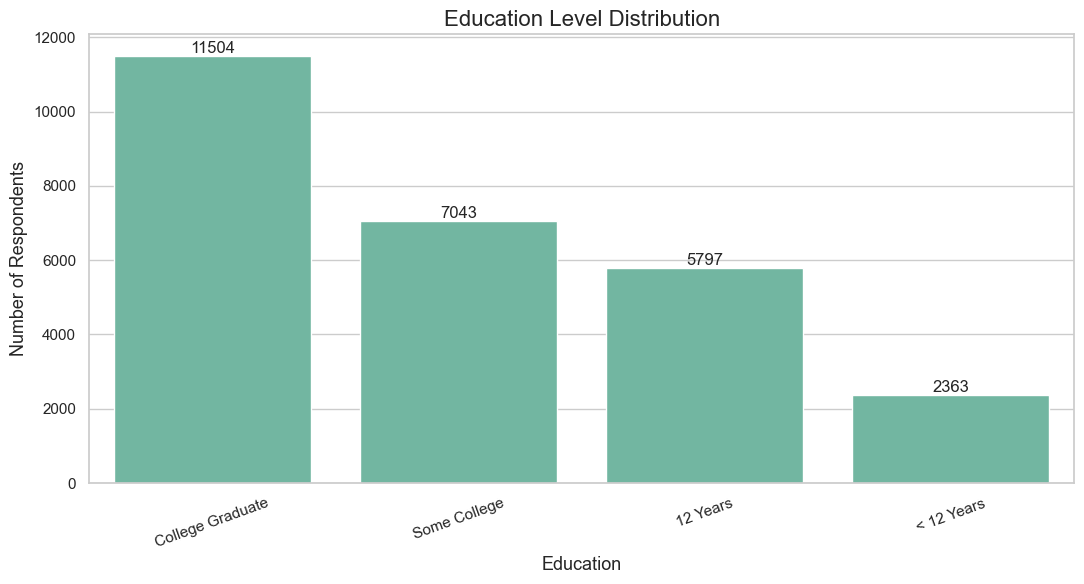

In [228]:
# Education Level Distribution

plt.figure(figsize=(11,6))

ax = sns.countplot(
    data=df,
    x="education",
    order=df["education"].value_counts().index
)

plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

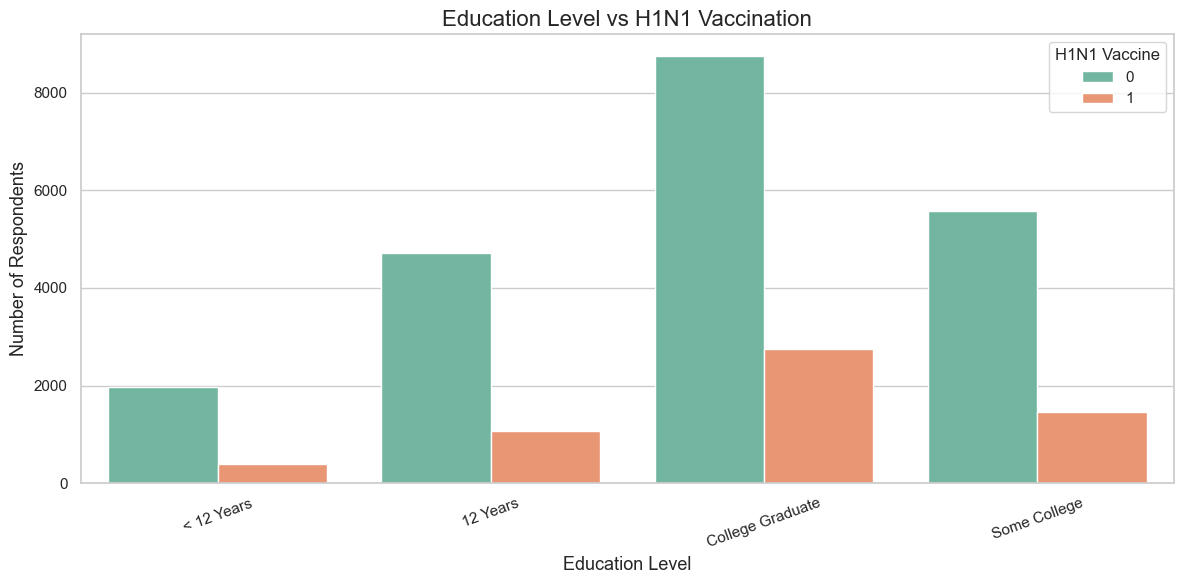

In [229]:
# Education vs H1N1 Vaccine

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="education",
    hue="h1n1_vaccine"
)

plt.title("Education Level vs H1N1 Vaccination")
plt.xlabel("Education Level")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.legend(title="H1N1 Vaccine")
plt.tight_layout()
plt.show()

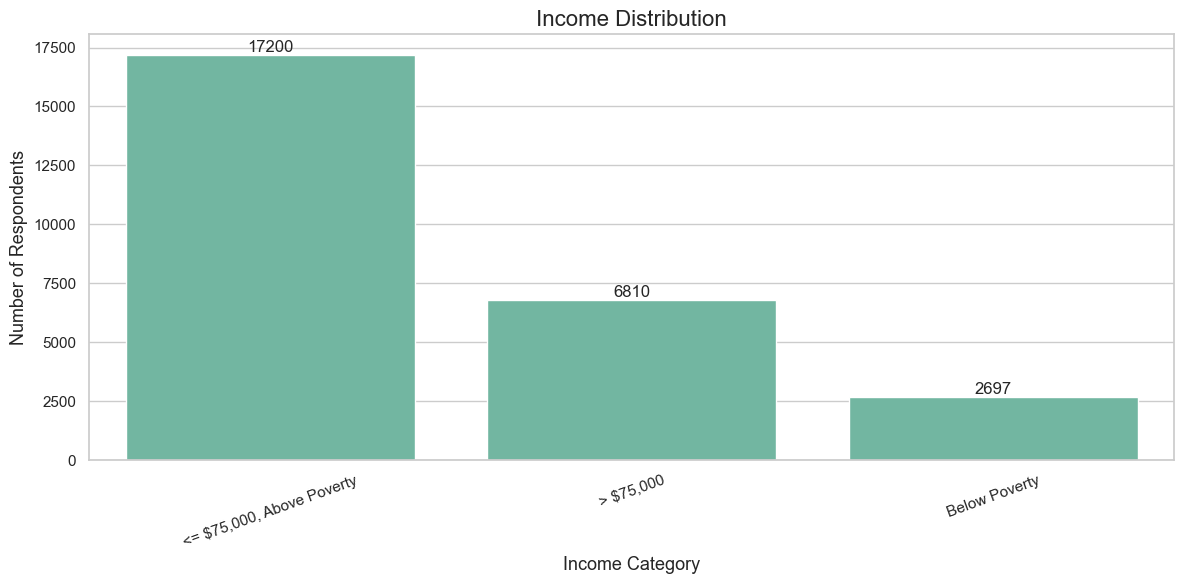

In [230]:
# Income Distribution

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="income_poverty",
    order=df["income_poverty"].value_counts().index
)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

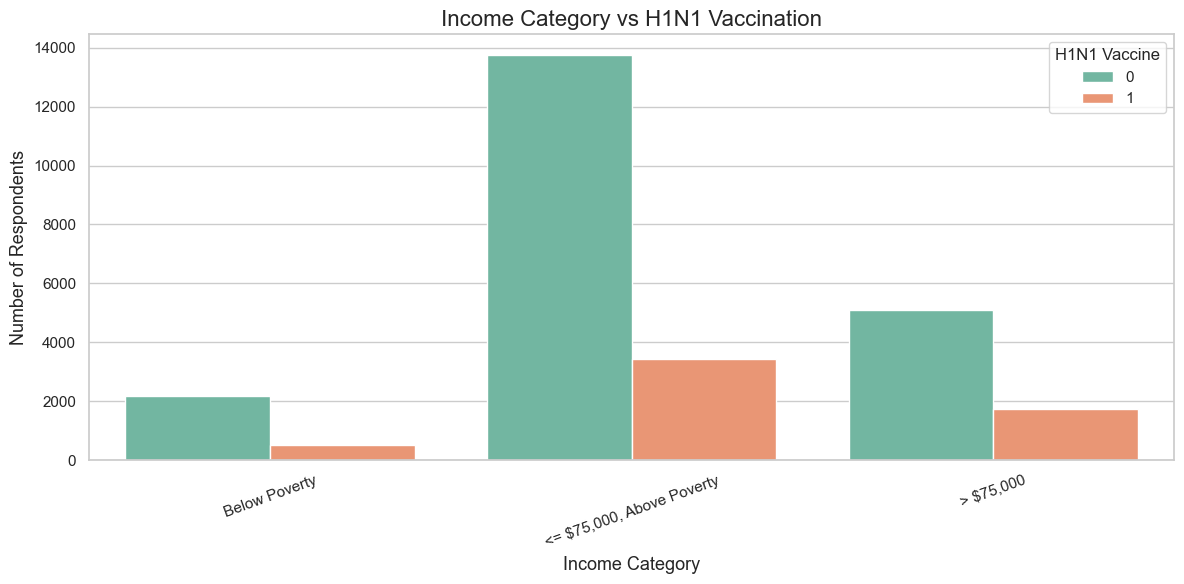

In [231]:
# Income Category vs H1N1 Vaccination

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="income_poverty",
    hue="h1n1_vaccine"
)

plt.title("Income Category vs H1N1 Vaccination")
plt.xlabel("Income Category")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=20)
plt.legend(title="H1N1 Vaccine")
plt.tight_layout()
plt.show()

#  Demographic Analysis Summary

### Business Insight

Demographic characteristics play an important role in vaccine adoption. Public health agencies can use these findings to design targeted awareness campaigns for specific age groups, education levels, and income categories.

### Machine Learning Insight

Features such as **age_group**, **education**, and **income_poverty** are likely to contribute significantly to predictive model performance and should be retained during feature engineering.

#  Health & Medical Analysis

## Why analyze health-related features?

Health-related characteristics directly influence an individual's decision to receive vaccination.

People with chronic illnesses, healthcare professionals, or those advised by doctors are generally more likely to get vaccinated.

Understanding these relationships helps:

- Identify high-risk populations.
- Understand healthcare influence on vaccination behavior.
- Improve feature selection for machine learning models.
- Generate actionable healthcare insights.

In this section, we analyze the relationship between health-related variables and vaccine uptake.

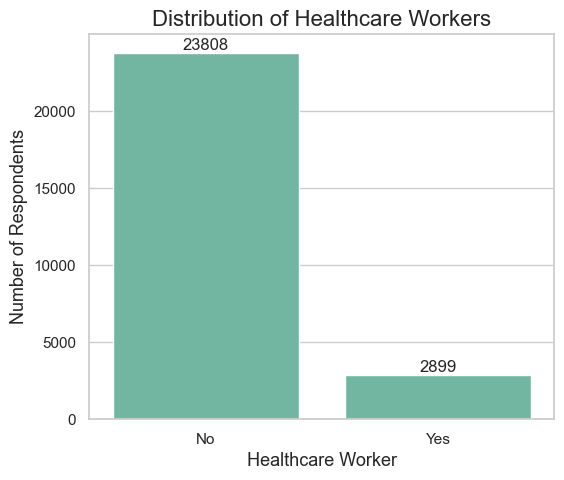

In [232]:
# Distribution of Healthcare Workers

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="health_worker"
)

plt.title("Distribution of Healthcare Workers")
plt.xlabel("Healthcare Worker")
plt.ylabel("Number of Respondents")
ax.set_xticklabels(["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

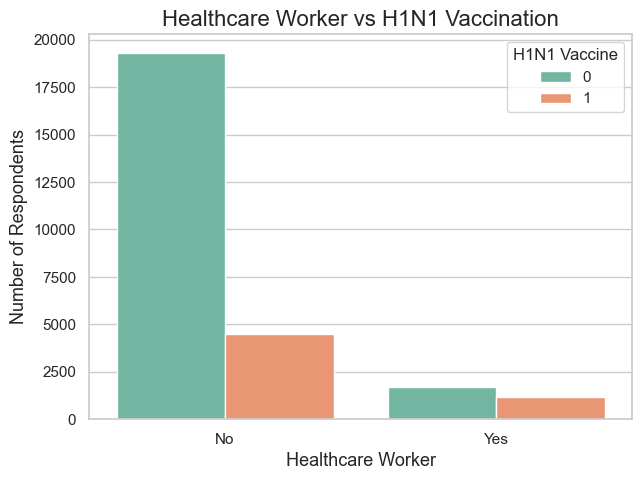

In [233]:
# Healthcare Worker vs H1N1 Vaccine

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="health_worker",
    hue="h1n1_vaccine"
)

plt.title("Healthcare Worker vs H1N1 Vaccination")
plt.xlabel("Healthcare Worker")
plt.ylabel("Number of Respondents")
ax.set_xticklabels(["No", "Yes"])
plt.legend(title="H1N1 Vaccine")
plt.show()

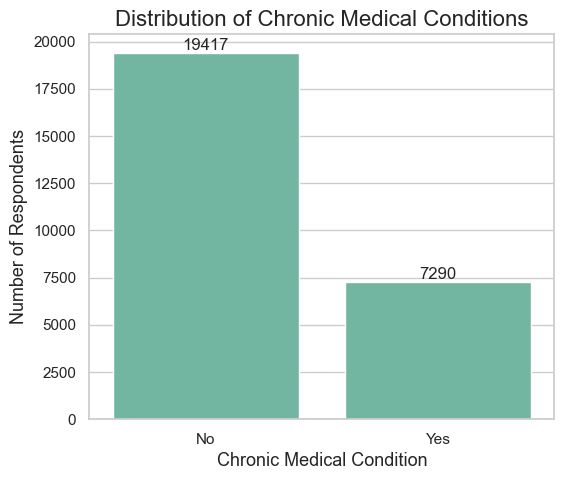

In [234]:
# Chronic Medical Condition Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="chronic_med_condition"
)

plt.title("Distribution of Chronic Medical Conditions")
plt.xlabel("Chronic Medical Condition")
plt.ylabel("Number of Respondents")
ax.set_xticklabels(["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

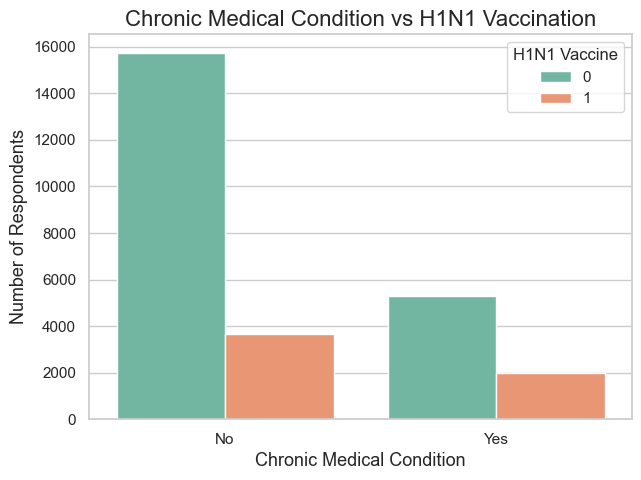

In [235]:
# Chronic Medical Condition vs H1N1 Vaccine

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="chronic_med_condition",
    hue="h1n1_vaccine"
)

plt.title("Chronic Medical Condition vs H1N1 Vaccination")
plt.xlabel("Chronic Medical Condition")
plt.ylabel("Number of Respondents")
plt.xticks([0,1],["No","Yes"])
plt.legend(title="H1N1 Vaccine")
plt.show()

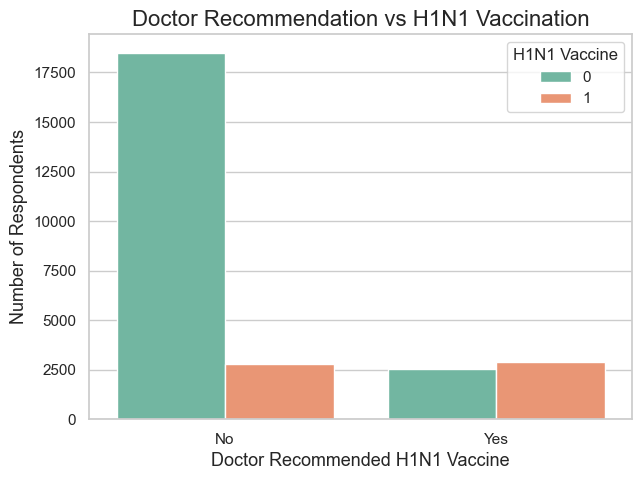

In [236]:
# Doctor Recommendation for H1N1 Vaccine

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="doctor_recc_h1n1",
    hue="h1n1_vaccine"
)

plt.title("Doctor Recommendation vs H1N1 Vaccination")
plt.xlabel("Doctor Recommended H1N1 Vaccine")
plt.ylabel("Number of Respondents")
plt.xticks([0,1],["No","Yes"])
plt.legend(title="H1N1 Vaccine")
plt.show()

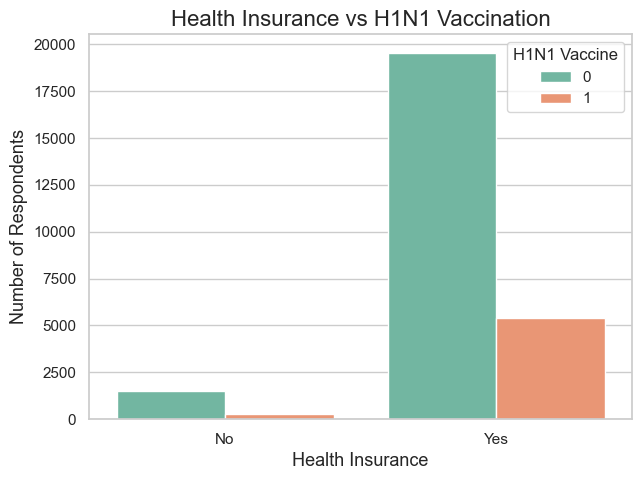

In [237]:
# Health Insurance vs H1N1 Vaccine

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="health_insurance",
    hue="h1n1_vaccine"
)

plt.title("Health Insurance vs H1N1 Vaccination")
plt.xlabel("Health Insurance")
plt.ylabel("Number of Respondents")
plt.xticks([0,1],["No","Yes"])
plt.legend(title="H1N1 Vaccine")
plt.show()

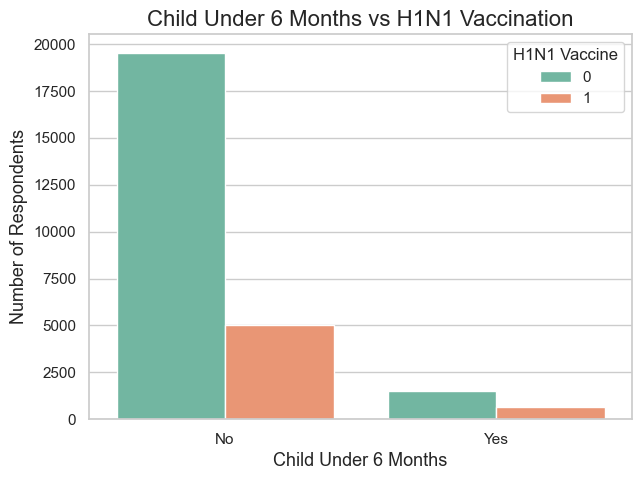

In [238]:
# Child Under 6 Months vs H1N1 Vaccine

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="child_under_6_months",
    hue="h1n1_vaccine"
)

plt.title("Child Under 6 Months vs H1N1 Vaccination")
plt.xlabel("Child Under 6 Months")
plt.ylabel("Number of Respondents")
plt.xticks([0,1],["No","Yes"])
plt.legend(title="H1N1 Vaccine")
plt.show()

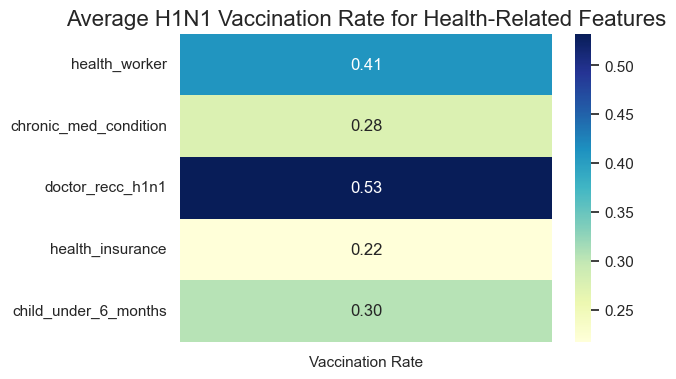

In [239]:
# Vaccination Rate by Health Features

health_features = [
    "health_worker",
    "chronic_med_condition",
    "doctor_recc_h1n1",
    "health_insurance",
    "child_under_6_months"
]

vaccination_rates = pd.DataFrame()

for feature in health_features:
    vaccination_rates.loc[feature, "Vaccination Rate"] = (
        df.groupby(feature)["h1n1_vaccine"]
          .mean()
          .loc[1]
    )

plt.figure(figsize=(6,4))

sns.heatmap(
    vaccination_rates,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average H1N1 Vaccination Rate for Health-Related Features")
plt.show()

#  Health Analysis Summary

### Business Insight

Healthcare-related variables have a substantial impact on vaccination behavior. These findings suggest that medical professionals and healthcare systems play a critical role in improving vaccination coverage.

### Machine Learning Insight

Features such as **doctor_recc_h1n1**, **health_worker**, and **chronic_med_condition** are expected to be among the most important predictors during model training.

#  Behavioral Analysis

## Why analyze behavioral features?

Behavioral features describe how individuals responded to the H1N1 pandemic through preventive measures.

These include:

- Wearing face masks
- Washing hands frequently
- Avoiding large gatherings
- Avoiding contact with sick people
- Taking antiviral medication

Understanding these behaviors helps identify whether health-conscious individuals are also more likely to receive vaccination.

These insights are valuable for both public health planning and predictive modeling.

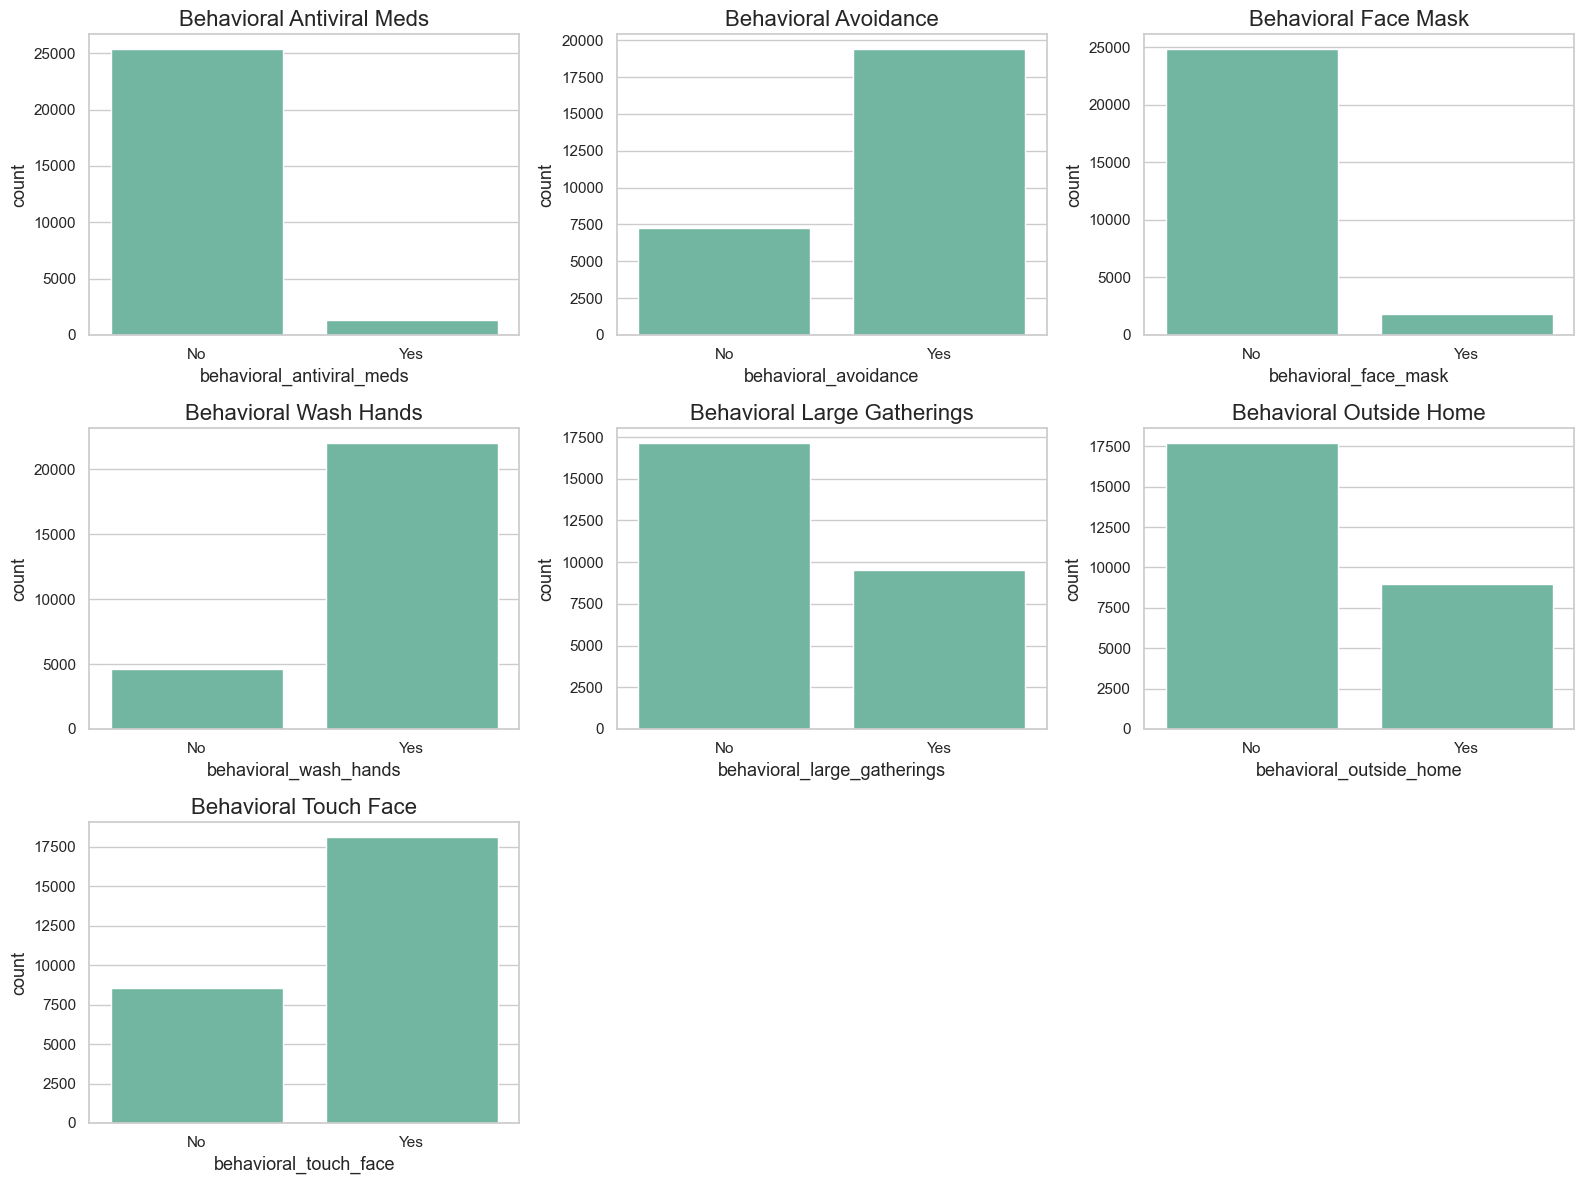

In [241]:
# Behavioral Features Distribution

behavior_features = [

    "behavioral_antiviral_meds",

    "behavioral_avoidance",

    "behavioral_face_mask",

    "behavioral_wash_hands",

    "behavioral_large_gatherings",

    "behavioral_outside_home",

    "behavioral_touch_face"

]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for index, feature in enumerate(behavior_features):
    
    sns.countplot(data=df,x=feature,ax=axes[index])
    axes[index].set_title(feature.replace("_", " ").title())
    axes[index].set_xticklabels(["No", "Yes"])

for index in range(len(behavior_features), len(axes)):
    fig.delaxes(axes[index])

plt.tight_layout()
plt.show()

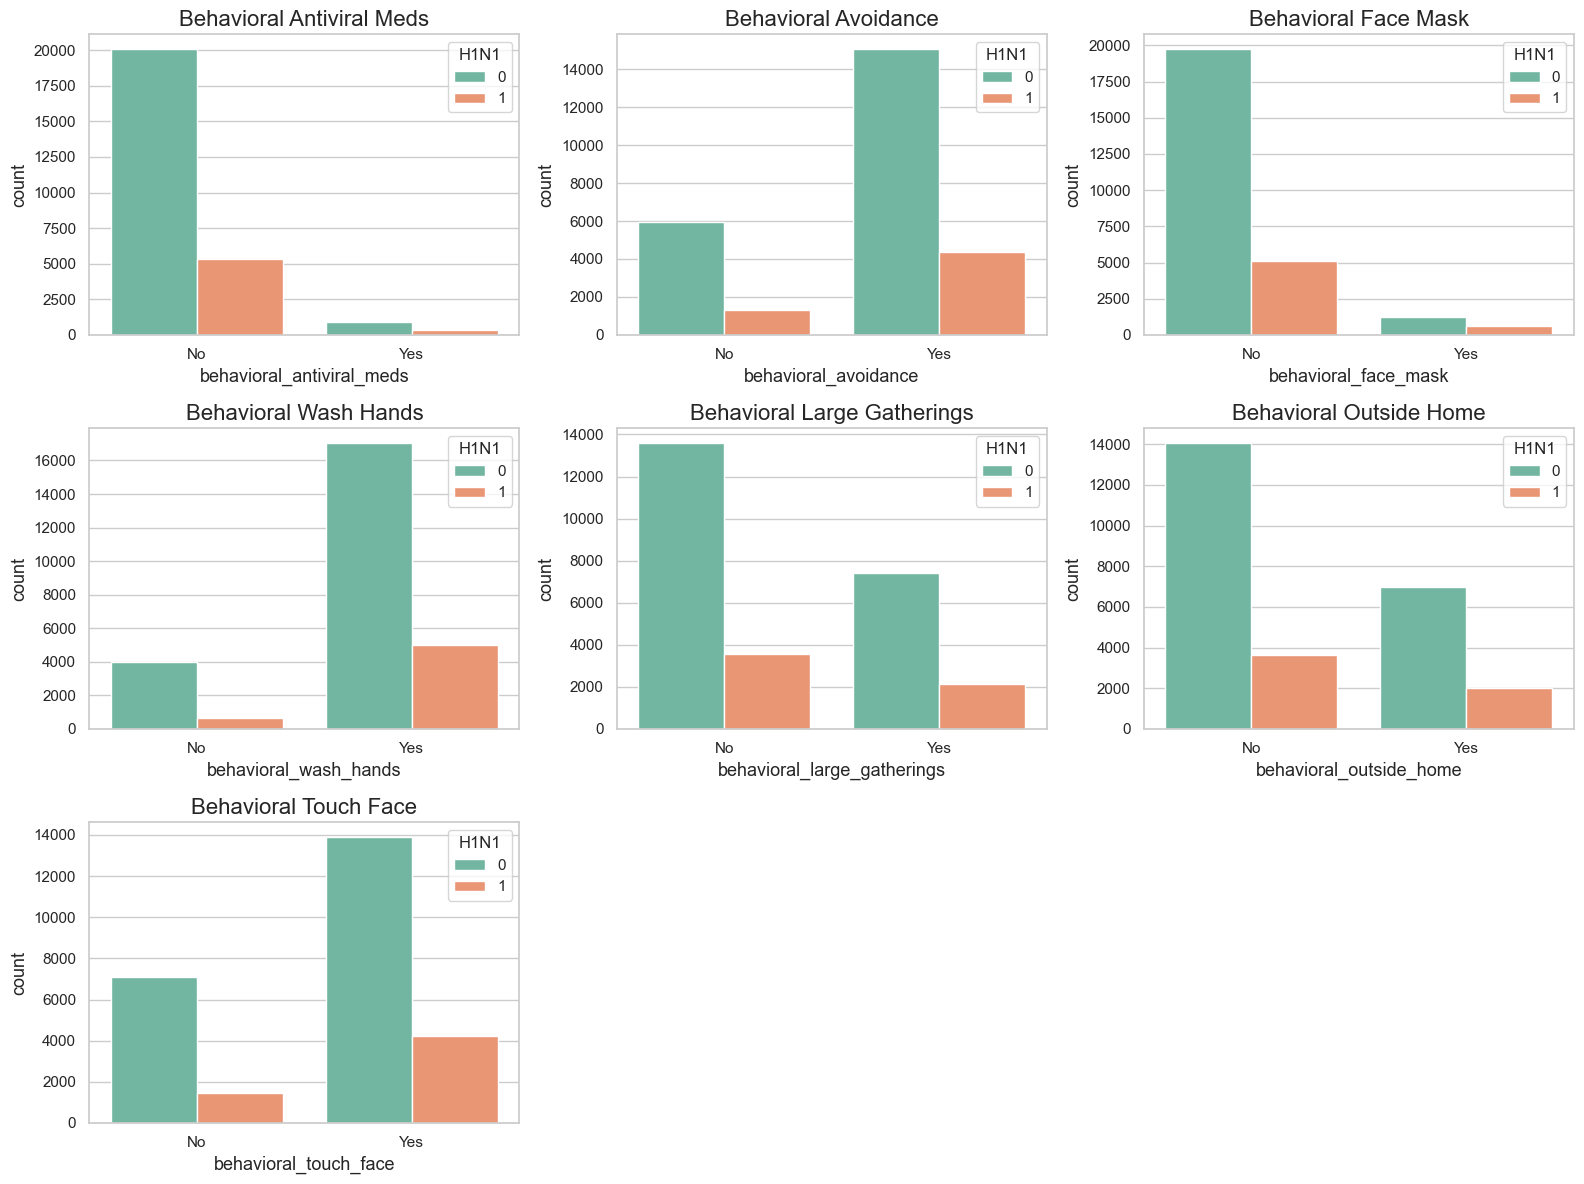

In [242]:
# Behavioral Features vs H1N1 Vaccine

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for index, feature in enumerate(behavior_features):
    
    sns.countplot(data=df,x=feature,hue="h1n1_vaccine",ax=axes[index])
    axes[index].set_title(feature.replace("_", " ").title())
    axes[index].set_xticklabels(["No", "Yes"])
    axes[index].legend(title="H1N1")

for index in range(len(behavior_features), len(axes)):

    fig.delaxes(axes[index])

plt.tight_layout()
plt.show()

In [243]:
# Average Vaccination Rate by Behavioral Features

behavior_rate = pd.DataFrame()
for feature in behavior_features:
    behavior_rate.loc[feature, "Vaccination Rate"] = (df.groupby(feature)["h1n1_vaccine"].mean().loc[1])
behavior_rate = behavior_rate.sort_values(by="Vaccination Rate",ascending=False)
display(behavior_rate)

,Vaccination Rate
behavioral_face_mask,0.318305
behavioral_antiviral_meds,0.285165
behavioral_touch_face,0.232390
behavioral_wash_hands,0.226459
behavioral_outside_home,0.225142
behavioral_avoidance,0.224172
behavioral_large_gatherings,0.222374


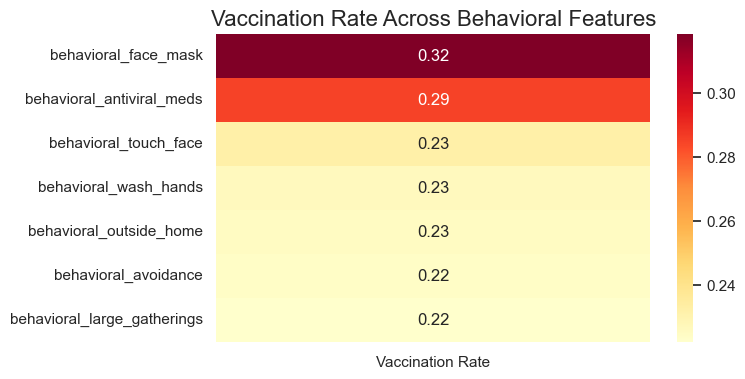

In [244]:
# Heatmap of Behavioral Vaccination Rates

plt.figure(figsize=(7,4))
sns.heatmap(
    behavior_rate,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Vaccination Rate Across Behavioral Features")
plt.show()

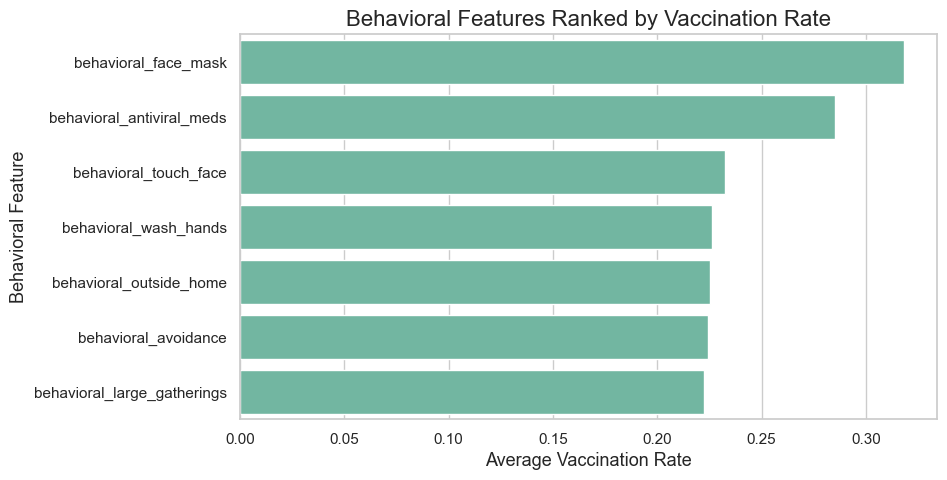

In [245]:
# Behavioral Features Ranked by Vaccination Rate

plt.figure(figsize=(9,5))
sns.barplot(
    data=behavior_rate.reset_index(),
    x="Vaccination Rate",
    y="index"
)

plt.title("Behavioral Features Ranked by Vaccination Rate")
plt.xlabel("Average Vaccination Rate")
plt.ylabel("Behavioral Feature")
plt.show()

#  Behavioral Analysis Summary

### Business Insight

Preventive behaviors indicate greater health awareness and are positively associated with vaccine acceptance.

Public health campaigns promoting preventive behavior may also increase vaccination coverage.

---

### Machine Learning Insight

Behavioral variables are expected to contribute significantly to predictive performance because they directly capture individual health awareness and risk perception.

#  Opinion & Perception Analysis

## Why analyze opinion-related features?

Vaccination decisions are not influenced only by demographic and health-related factors. People's beliefs, knowledge, and perceptions about vaccines also play a major role.

Understanding these opinions helps answer questions such as:

- Does greater concern about H1N1 increase vaccination?
- Does vaccine knowledge improve acceptance?
- Do people who believe vaccines are effective receive them more frequently?
- Does perceived risk influence vaccination behavior?

These insights are extremely valuable for designing effective vaccination awareness campaigns and improving predictive model performance.

---

## Features Covered

- H1N1 Concern
- H1N1 Knowledge
- H1N1 Vaccine Effectiveness
- H1N1 Risk Perception
- Fear of Getting Sick from Vaccine

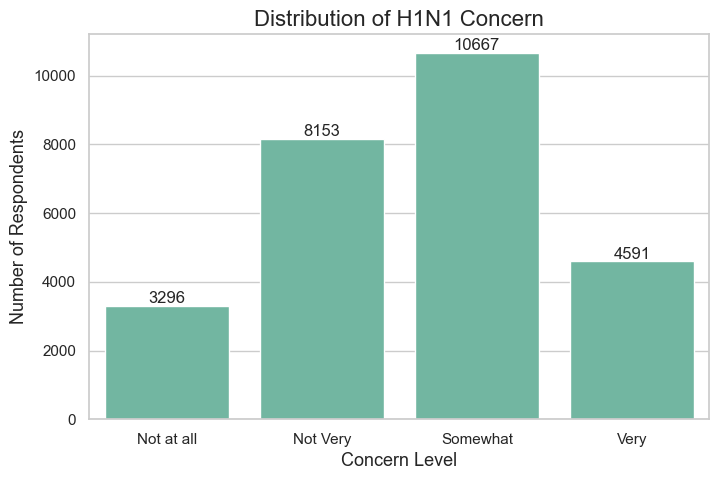

In [246]:
# H1N1 Concern Distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="h1n1_concern"
)

plt.title("Distribution of H1N1 Concern")
plt.xlabel("Concern Level")
plt.ylabel("Number of Respondents")
ax.set_xticklabels([
    "Not at all",
    "Not Very",
    "Somewhat",
    "Very"
])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

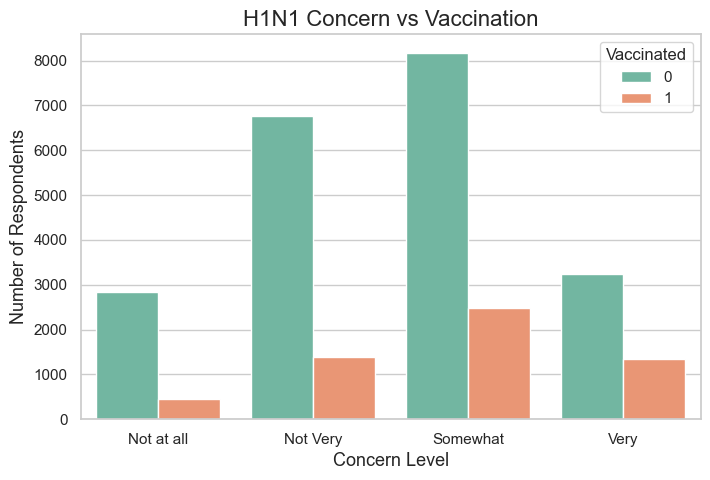

In [247]:
# H1N1 Concern vs Vaccination

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="h1n1_concern",
    hue="h1n1_vaccine"
)

plt.title("H1N1 Concern vs Vaccination")
plt.xlabel("Concern Level")
plt.ylabel("Number of Respondents")
plt.xticks(
    ticks=[0,1,2,3],
    labels=[
        "Not at all",
        "Not Very",
        "Somewhat",
        "Very"
    ]
)

plt.legend(title="Vaccinated")
plt.show()

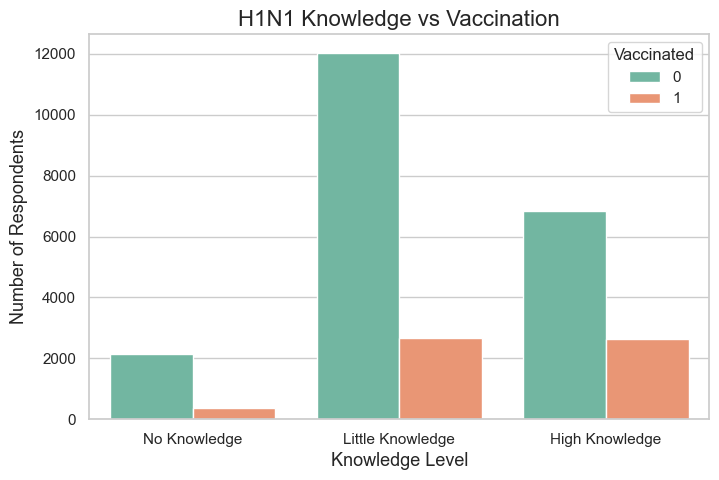

In [248]:
# H1N1 Knowledge vs Vaccination

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="h1n1_knowledge",
    hue="h1n1_vaccine"
)

plt.title("H1N1 Knowledge vs Vaccination")
plt.xlabel("Knowledge Level")
plt.ylabel("Number of Respondents")
plt.xticks(
    ticks=[0,1,2],
    labels=[
        "No Knowledge",
        "Little Knowledge",
        "High Knowledge"
    ]
)

plt.legend(title="Vaccinated")
plt.show()

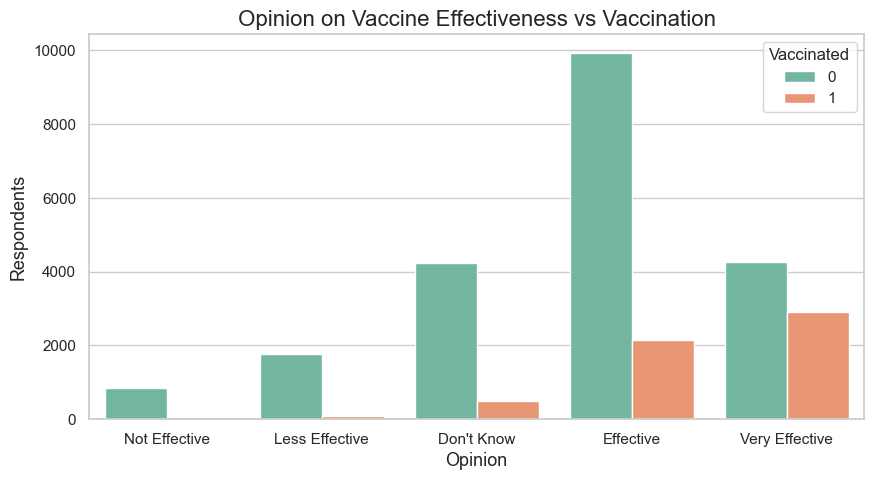

In [249]:
# Opinion on Vaccine Effectiveness

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="opinion_h1n1_vacc_effective",
    hue="h1n1_vaccine"
)

plt.title("Opinion on Vaccine Effectiveness vs Vaccination")
plt.xlabel("Opinion")
plt.ylabel("Respondents")
plt.xticks(
    ticks=[0,1,2,3,4],
    labels=[
        "Not Effective",
        "Less Effective",
        "Don't Know",
        "Effective",
        "Very Effective"
    ]
)

plt.legend(title="Vaccinated")
plt.show()

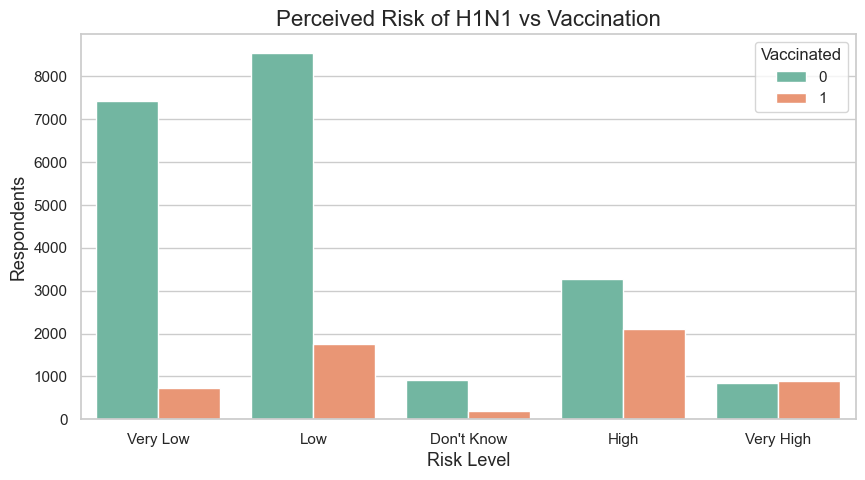

In [250]:
# Perceived Risk vs Vaccination

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="opinion_h1n1_risk",
    hue="h1n1_vaccine"
)

plt.title("Perceived Risk of H1N1 vs Vaccination")
plt.xlabel("Risk Level")
plt.ylabel("Respondents")
plt.xticks(
    ticks=[0,1,2,3,4],
    labels=[
        "Very Low",
        "Low",
        "Don't Know",
        "High",
        "Very High"
    ]
)

plt.legend(title="Vaccinated")
plt.show()

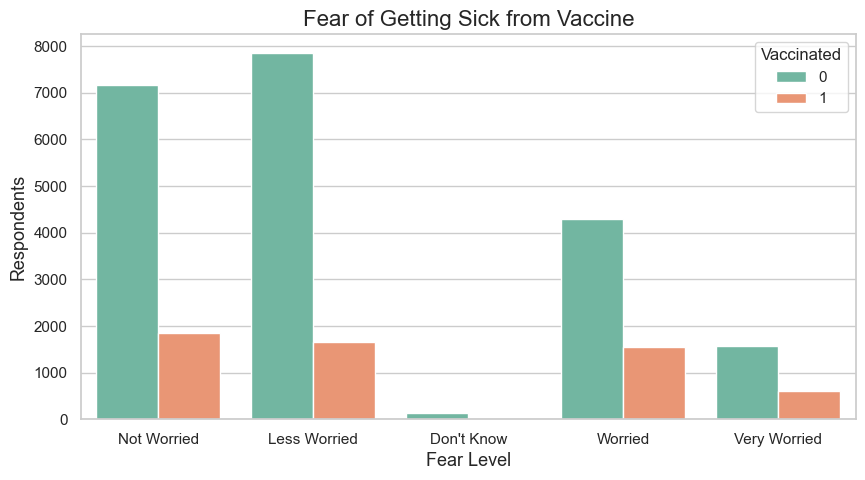

In [251]:
# Fear of Getting Sick from Vaccine

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="opinion_h1n1_sick_from_vacc",
    hue="h1n1_vaccine"
)

plt.title("Fear of Getting Sick from Vaccine")
plt.xlabel("Fear Level")
plt.ylabel("Respondents")
plt.xticks(
    ticks=[0,1,2,3,4],
    labels=[
        "Not Worried",
        "Less Worried",
        "Don't Know",
        "Worried",
        "Very Worried"
    ]
)

plt.legend(title="Vaccinated")
plt.show()

In [252]:
# Opinion Analysis Summary

opinion_summary = pd.DataFrame({
    "Feature": [
        "H1N1 Concern",
        "Knowledge",
        "Vaccine Effectiveness",
        "Risk Perception",
        "Fear of Vaccine"
    ],
    "Business Importance": [
        "High",
        "High",
        "Very High",
        "Very High",
        "Medium"
    ],
    "Expected ML Importance": [
        "High",
        "High",
        "Very High",
        "Very High",
        "Medium"
    ]
})

display(opinion_summary)

,Feature,Business Importance,Expected ML Importance
0,H1N1 Concern,High,High
1,Knowledge,High,High
2,Vaccine Effectiveness,Very High,Very High
3,Risk Perception,Very High,Very High
4,Fear of Vaccine,Medium,Medium


#  Opinion & Perception Analysis Summary

---

### Business Insight

Public awareness and education campaigns can significantly improve vaccination coverage by increasing knowledge, addressing misconceptions, and emphasizing vaccine effectiveness.

---

### Machine Learning Insight

Opinion-related variables are expected to be among the strongest predictors in the machine learning models and should be retained during feature selection.

#  Correlation & Statistical Analysis

## Why Correlation Analysis?

Correlation analysis helps identify relationships between variables and the target variable.

Benefits:

- Understand feature relationships.
- Detect highly correlated variables.
- Identify useful predictors.
- Support feature selection before model building.

In this section, we will analyze:

- Correlation Heatmap
- Target Correlation
- Statistical Significance (Chi-Square Test)
- Feature Importance Ranking

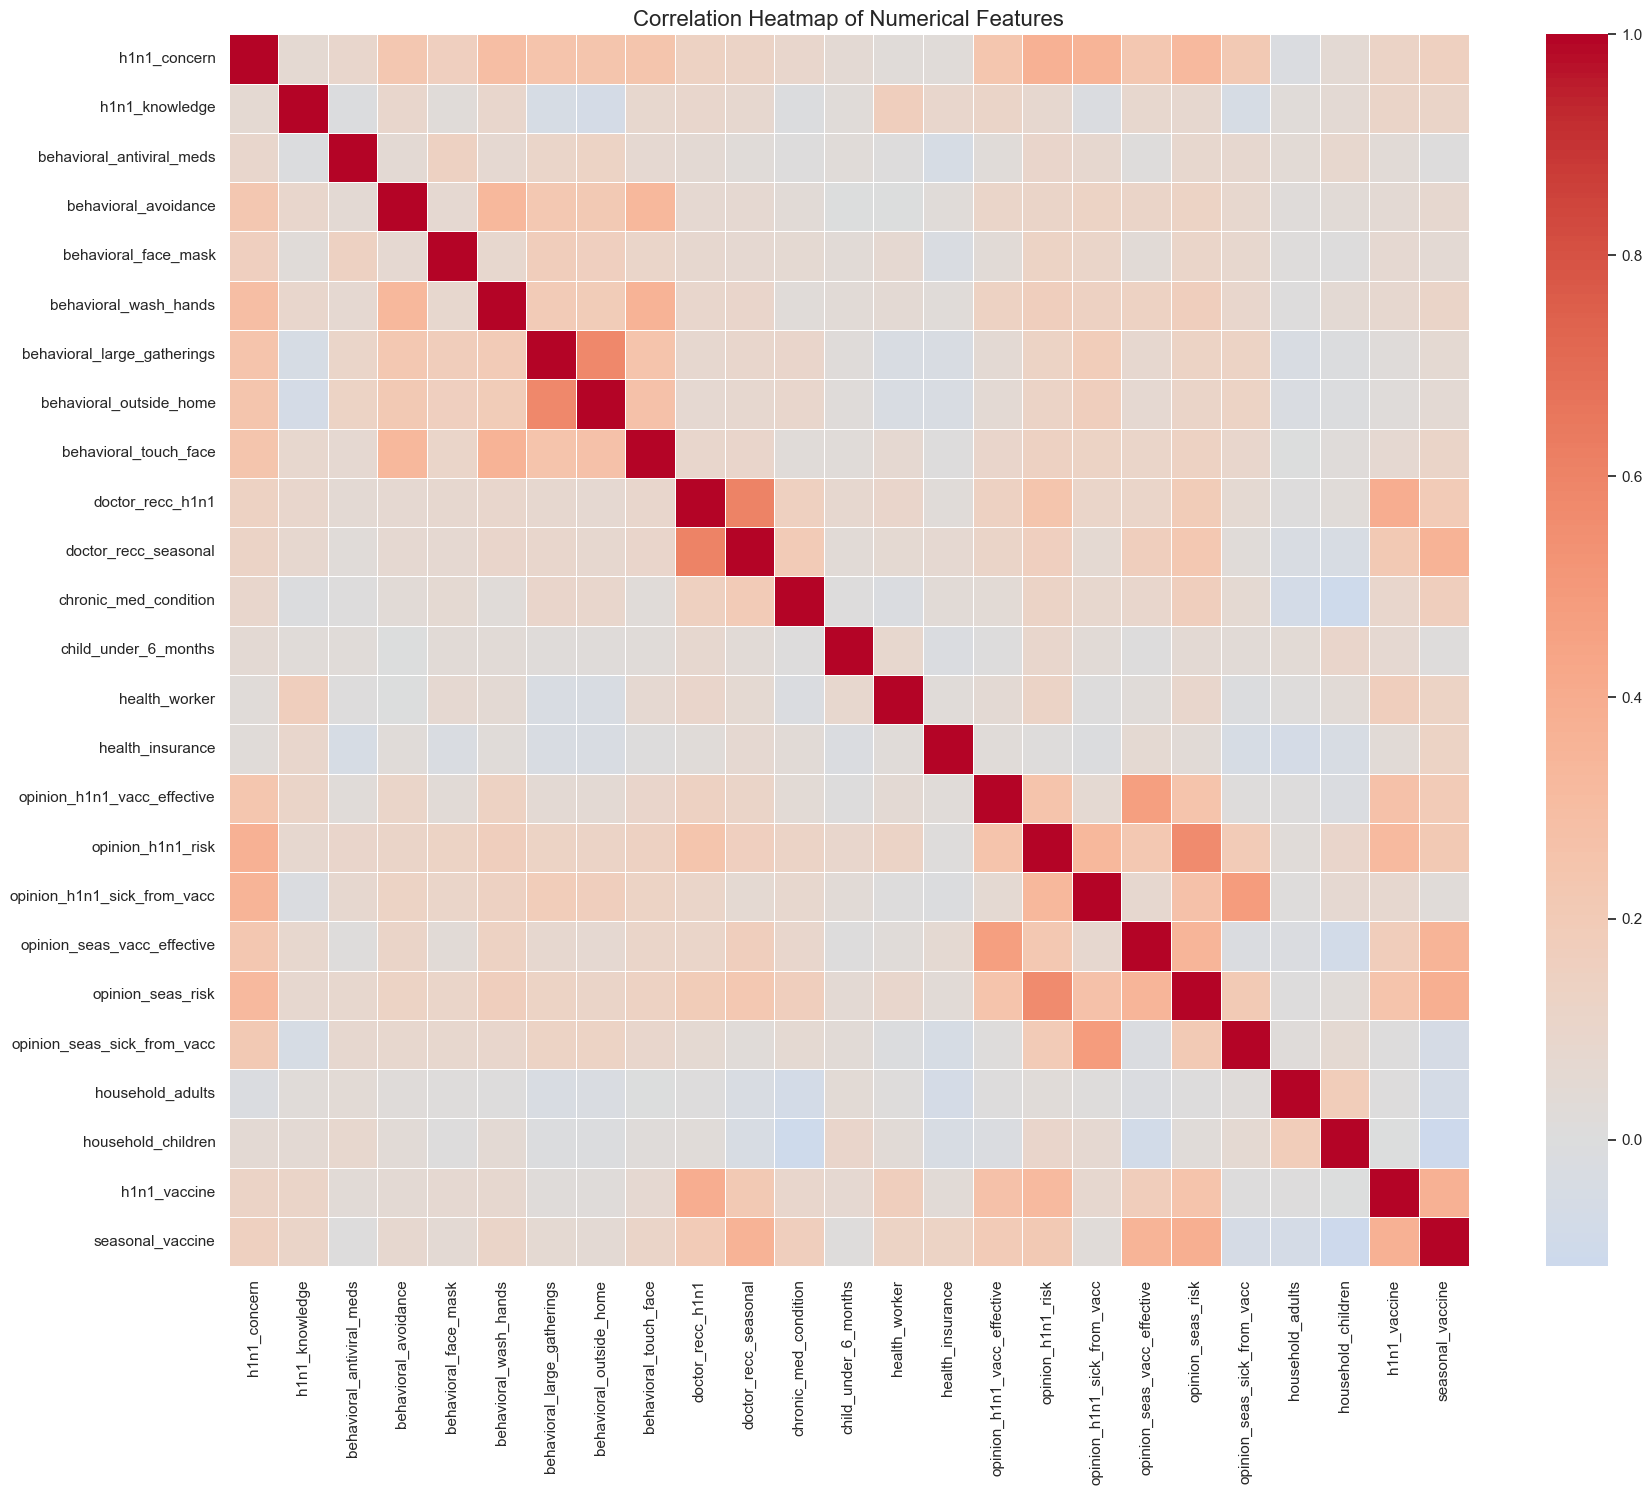

In [253]:
# Correlation Heatmap

# Select only numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Observation

Observe whether any variables are highly correlated.

Generally,

- Correlation > 0.80 indicates strong positive correlation.
- Correlation < -0.80 indicates strong negative correlation.
- The correlation heatmap shows relationships among numerical features.
- Most features exhibit low to moderate correlation.
- No severe multicollinearity is observed that would negatively impact model performance.

---

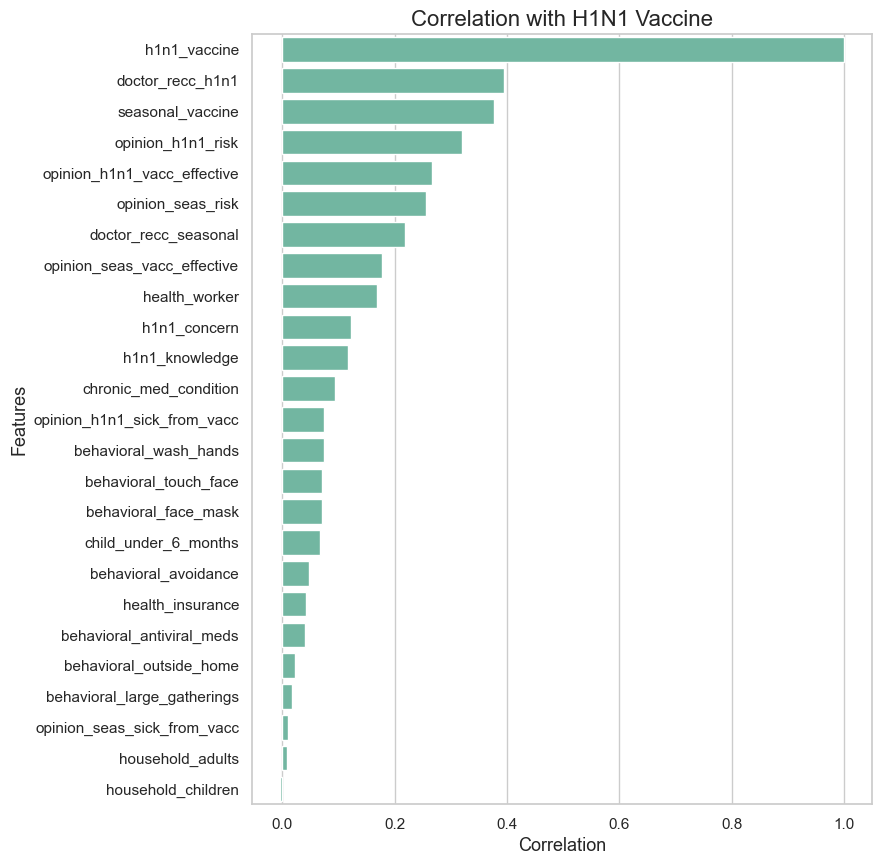

In [254]:
# Correlation with H1N1 Vaccine

target_corr = (correlation_matrix["h1n1_vaccine"].sort_values(ascending=False))
plt.figure(figsize=(8,10))
sns.barplot(x=target_corr.values,y=target_corr.index)
plt.title("Correlation with H1N1 Vaccine")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [255]:
# Top Features Correlated with H1N1 Vaccine

top_features = target_corr.drop("h1n1_vaccine").head(15)
display(top_features)

doctor_recc_h1n1               0.394086
seasonal_vaccine               0.377143
opinion_h1n1_risk              0.320580
opinion_h1n1_vacc_effective    0.267352
opinion_seas_risk              0.255874
doctor_recc_seasonal           0.218976
opinion_seas_vacc_effective    0.177799
health_worker                  0.168056
h1n1_concern                   0.121574
h1n1_knowledge                 0.117771
chronic_med_condition          0.094360
opinion_h1n1_sick_from_vacc    0.074580
behavioral_wash_hands          0.074570
behavioral_touch_face          0.070855
behavioral_face_mask           0.070413
Name: h1n1_vaccine, dtype: float64

#  Chi-Square Test

## Why use the Chi-Square Test?

The Chi-Square Test measures whether a categorical feature has a statistically significant association with the target variable.

If the p-value is less than 0.05, we conclude that the feature has a significant relationship with vaccination behavior.

In [256]:
# Import Statistical Library
# Chi-Square Test for All Categorical Features

from scipy.stats import chi2_contingency

categorical_features = [
    column
    for column in df.columns
    if df[column].dtype == "object"
]

results = []
for feature in categorical_features:
    contingency_table = pd.crosstab(
        df[feature],
        df["h1n1_vaccine"]
    )
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        "Feature": feature,
        "P-value": round(p,5),
        "Significant": "Yes" if p < 0.05 else "No"
    })
chi_square_results = pd.DataFrame(results)
chi_square_results = chi_square_results.sort_values("P-value")
display(chi_square_results)

,Feature,P-value,Significant
0,age_group,0.00000,Yes
1,education,0.00000,Yes
2,race,0.00000,Yes
4,income_poverty,0.00000,Yes
5,marital_status,0.00000,Yes
6,rent_or_own,0.00000,Yes
8,hhs_geo_region,0.00000,Yes
10,employment_industry,0.00000,Yes
11,employment_occupation,0.00000,Yes
7,employment_status,0.00001,Yes


In [257]:
# Chi-Square Test for All Categorical Features

excluded_columns = [
    "h1n1_vaccine",
    "seasonal_vaccine"
]
chi_square_results = []
for column in df.columns:
    if column not in excluded_columns:
        contingency_table = pd.crosstab(df[column],df["h1n1_vaccine"])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        chi_square_results.append({
            "Feature": column,
            "Chi-Square": round(chi2,2),
            "P-value": round(p,5),
            "Significant": "Yes" if p < 0.05 else "No"
        })

chi_square_results = pd.DataFrame(chi_square_results)
chi_square_results = chi_square_results.sort_values(by="P-value")
display(chi_square_results)

,Feature,Chi-Square,P-value,Significant
0,h1n1_concern,400.46,0.00000,Yes
31,household_adults,30.47,0.00000,Yes
29,hhs_geo_region,92.47,0.00000,Yes
27,rent_or_own,25.45,0.00000,Yes
26,marital_status,54.33,0.00000,Yes
25,income_poverty,90.84,0.00000,Yes
23,race,57.01,0.00000,Yes
22,education,103.19,0.00000,Yes
21,age_group,69.45,0.00000,Yes
20,opinion_seas_sick_from_vacc,45.13,0.00000,Yes


In [258]:
# Significant Features

significant_features = chi_square_results[chi_square_results["Significant"] == "Yes"]
display(significant_features)

,Feature,Chi-Square,P-value,Significant
0,h1n1_concern,400.46,0.00000,Yes
31,household_adults,30.47,0.00000,Yes
29,hhs_geo_region,92.47,0.00000,Yes
27,rent_or_own,25.45,0.00000,Yes
26,marital_status,54.33,0.00000,Yes
25,income_poverty,90.84,0.00000,Yes
23,race,57.01,0.00000,Yes
22,education,103.19,0.00000,Yes
21,age_group,69.45,0.00000,Yes
20,opinion_seas_sick_from_vacc,45.13,0.00000,Yes


In [259]:
# Statistical Summary

print(f"Total Features Tested      : {len(chi_square_results)}")
print(f"Significant Features       : {len(significant_features)}")
print(f"Non-Significant Features   : {len(chi_square_results) - len(significant_features)}")

Total Features Tested      : 35
Significant Features       : 33
Non-Significant Features   : 2


#  Correlation & Statistical Analysis Summary

### Business Insight

Statistical testing provides evidence-based support for identifying the factors that influence vaccination decisions. These insights can help public health organizations prioritize awareness campaigns and interventions.

---

### Machine Learning Insight

Features with statistically significant associations should be retained for model development, while non-significant features can be evaluated further during feature selection and model optimization.

#  Feature Engineering & Data Preparation

## Why is Feature Engineering Important?

Machine learning models cannot directly understand categorical variables. Before training models, the dataset must be transformed into a numerical format while preserving meaningful information.

The main objectives of this step are:

- Separate input and target variables.
- Encode categorical variables.
- Split the data into training and testing datasets.
- Scale numerical features where required.
- Prevent data leakage by fitting preprocessing only on the training data.

A well-designed preprocessing pipeline improves model performance and ensures fair evaluation.

In [260]:
# Separate Features and Target (H1N1 Vaccine)

X = df.drop(
    columns=[
        "h1n1_vaccine",
        "seasonal_vaccine"
    ]
)

y = df["h1n1_vaccine"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (26707, 35)
Target Shape         : (26707,)


In [261]:
# Identify Numerical and Categorical Features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print(f"Categorical Features : {len(categorical_features)}")
print(f"Numerical Features   : {len(numerical_features)}")

Categorical Features : 12
Numerical Features   : 23


## Why OneHotEncoder?

Machine learning algorithms require numerical inputs. OneHotEncoder converts categorical variables into binary indicator columns without introducing any ordinal relationship between categories.

Using OneHotEncoder inside a preprocessing pipeline ensures that the same transformations are consistently applied to both training and testing data.

In [262]:
# Import Preprocessing Libraries

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [263]:
# Numerical Preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical Preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Why Train-Test Split?

The dataset is divided into training and testing sets to evaluate the model on unseen data.

- Training Set → Used to train the model.
- Testing Set → Used to evaluate the model.

This ensures that the model generalizes well and does not simply memorize the training data.

In [264]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (21365, 35)
Testing Features  : (5342, 35)
Training Labels   : (21365,)
Testing Labels    : (5342,)


## Why didn't we apply StandardScaler?

Not all machine learning algorithms require feature scaling.

Algorithms such as:

- Decision Tree
- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

are tree-based and do not depend on feature magnitude.

Scaling will only be applied for models that benefit from it, such as:

- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbors

This approach avoids unnecessary preprocessing while keeping the pipeline efficient.

#  Machine Learning Model Development

## Objective

The objective of this section is to train multiple machine learning algorithms and compare their performance for predicting H1N1 vaccine uptake.

Rather than relying on a single algorithm, multiple models will be evaluated to identify the most suitable model for production.

The evaluation will be based on:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

This comparative approach ensures that the selected model provides the best balance between predictive performance and generalization.

In [265]:
# Import Machine Learning Algorithms

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.pipeline import Pipeline

In [266]:
# Model Evaluation Function

def evaluate_model(model, model_name):
    """
    Train and evaluate a machine learning model.

    Parameters:
        model (object): Machine Learning model
        model_name (str): Name of the model

    Returns:
        dict: Performance metrics
    """

    # Create pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Prediction probabilities (if available)
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    # Calculate metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

    print(f"{model_name}")
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))
    print("\nPerformance Metrics\n")

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric:<15}: {value:.4f}")

    return results

## Baseline Model - Logistic Regression

Logistic Regression is selected as the baseline model because:

- It is simple and interpretable.
- It performs well on binary classification problems.
- It provides a benchmark for comparing advanced algorithms.

The performance of more complex models will be compared against this baseline.

In [268]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_results = evaluate_model(
    logistic_model,
    "Logistic Regression"
)

Logistic Regression

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4207
           1       0.67      0.44      0.53      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.69      0.72      5342
weighted avg       0.82      0.84      0.82      5342


Confusion Matrix

[[3964  243]
 [ 632  503]]

Performance Metrics

Accuracy       : 0.8362
Precision      : 0.6743
Recall         : 0.4432
F1 Score       : 0.5348
ROC AUC        : 0.8289


In [269]:
# Initialize Model Performance Table

model_results = []
model_results.append(logistic_results)
results_df = pd.DataFrame(model_results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.836204,0.674263,0.443172,0.534822,0.828883


#  Feature Encoding

## Why is Feature Encoding Required?

Machine learning algorithms require numerical input. While many features in this dataset are already represented using numerical values, some columns still contain text-based categorical values.

These categorical variables must be converted into numerical representations before training machine learning models.

In this project, Label Encoding is used because:

- Most categorical features are nominal.
- Tree-based models work efficiently with integer-encoded categories.
- It keeps the dataset compact and easy to interpret.

In [270]:
# Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

# Create a copy of the cleaned dataset
df_encoded = df.copy()

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Identify object columns
categorical_columns = df_encoded.select_dtypes(include=["object"]).columns

# Encode each categorical feature
for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

print("Categorical feature encoding completed successfully.")

Categorical feature encoding completed successfully.


In [271]:
# Verify Encoded Dataset
df_encoded.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,3,1,3,0,2,1,0,1,8,2,0.0,0.0,0,0,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,1,0,3,1,2,1,1,0,1,0,0.0,0.0,13,20,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,0,2,3,1,0,1,0,0,9,0,2.0,0.0,15,22,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,5.0,5.0,4.0,1.0,4,0,3,0,2,1,1,1,5,1,0.0,0.0,0,0,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,2.0,3.0,1.0,4.0,2,3,3,0,0,0,0,0,9,0,1.0,0.0,19,6,0,0


In [272]:
# Separate Features and Target Variable

X = df_encoded.drop(
    columns=[
        "h1n1_vaccine",
        "seasonal_vaccine"
    ]
)

y = df_encoded["h1n1_vaccine"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (26707, 35)
Target Shape         : (26707,)


In [273]:
# Split Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (21365, 35)
Testing Features  : (5342, 35)
Training Labels   : (21365,)
Testing Labels    : (5342,)


#  Feature Scaling

Feature scaling standardizes numerical features so that they have similar ranges.

Scaling is beneficial for algorithms such as:

- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbors

Tree-based algorithms such as Random Forest, XGBoost, LightGBM, CatBoost, and Decision Trees do not require feature scaling.

In [274]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed successfully.")

Feature scaling completed successfully.


#  Model Training and Evaluation

## Why create an evaluation function?

When working with multiple machine learning models, writing the same evaluation code repeatedly makes the notebook longer and harder to maintain.

Creating a reusable evaluation function allows us to:

- Train different models using the same workflow.
- Evaluate each model consistently.
- Compare model performance fairly.
- Reduce duplicate code.
- Improve notebook readability and maintainability.

The following metrics will be used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

In [275]:

# Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    # Performance Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # Print Results
    print(f"{model_name}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

#  Logistic Regression

## Why Logistic Regression?

Logistic Regression is one of the most widely used algorithms for binary classification problems.

Advantages:

- Easy to interpret.
- Fast to train.
- Performs well on linearly separable data.
- Serves as a strong baseline model.

The performance of advanced models will be compared against this baseline.

In [107]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Check Remaining Missing Values
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print("\nTotal Missing Values:", missing_values.sum())

h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
household_adults                 249
household_children               249
dtype: int64

Total Missing Values: 23219


In [276]:
# Fill Remaining Missing Values

for column in X.columns:
    if X[column].dtype == "object":
        X[column] = X[column].fillna(X[column].mode()[0])
    else:
        X[column] = X[column].fillna(X[column].median())
print("Remaining Missing Values:", X.isnull().sum().sum())

Remaining Missing Values: 0


In [277]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [278]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [279]:
model_results = []

In [280]:
# Train Logistic Regression Model

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    model=logistic_model,
    model_name="Logistic Regression",
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test
)

Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.69      0.43      0.53      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.69      0.71      5342
weighted avg       0.82      0.84      0.82      5342


Confusion Matrix:

[[3987  220]
 [ 652  483]]


In [281]:
# View Current Model Results

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804


#  Decision Tree Classifier

## Why Decision Tree?

Decision Tree is a supervised machine learning algorithm used for classification and regression tasks.

### Advantages

- Easy to understand and interpret.
- Handles non-linear relationships.
- Does not require feature scaling.
- Captures feature interactions effectively.

Decision Trees are often used as a baseline tree-based model before training ensemble methods such as Random Forest and XGBoost.

In [282]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

evaluate_model(
    model=decision_tree,
    model_name="Decision Tree",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Decision Tree

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4207
           1       0.58      0.41      0.48      1135

    accuracy                           0.81      5342
   macro avg       0.72      0.66      0.68      5342
weighted avg       0.79      0.81      0.80      5342


Confusion Matrix:

[[3878  329]
 [ 675  460]]


In [283]:
# Display Updated Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
1,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


#  Decision Tree Summary

### Observations

(Update after executing the model.)

Example:

- The Decision Tree captured non-linear patterns in the data.
- Compared with Logistic Regression, the model may improve recall but can overfit if not properly tuned.

### Business Insight

Decision Trees are intuitive and can help identify the most influential factors affecting vaccination decisions.

### Machine Learning Insight

Although Decision Trees are easy to interpret, ensemble methods such as Random Forest and Gradient Boosting often achieve better predictive performance by reducing overfitting.

#  Random Forest Classifier

## Why Random Forest?

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

### Advantages

- Handles non-linear relationships effectively.
- Robust to noise and outliers.
- Reduces overfitting compared to a single Decision Tree.
- Provides feature importance scores.
- Does not require feature scaling.

Random Forest is commonly used as a strong baseline for classification problems and often delivers excellent performance with minimal tuning.

In [284]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

evaluate_model(
    model=random_forest,
    model_name="Random Forest",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4207
           1       0.72      0.39      0.51      1135

    accuracy                           0.84      5342
   macro avg       0.78      0.68      0.71      5342
weighted avg       0.82      0.84      0.82      5342


Confusion Matrix:

[[4029  178]
 [ 688  447]]


In [285]:
# Update Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
1,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
2,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [286]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
9,doctor_recc_h1n1,0.187965
16,opinion_h1n1_risk,0.116257
15,opinion_h1n1_vacc_effective,0.102891
19,opinion_seas_risk,0.053251
29,hhs_geo_region,0.036631
18,opinion_seas_vacc_effective,0.034194
34,employment_occupation,0.034103
13,health_worker,0.031947
33,employment_industry,0.030895
10,doctor_recc_seasonal,0.030783


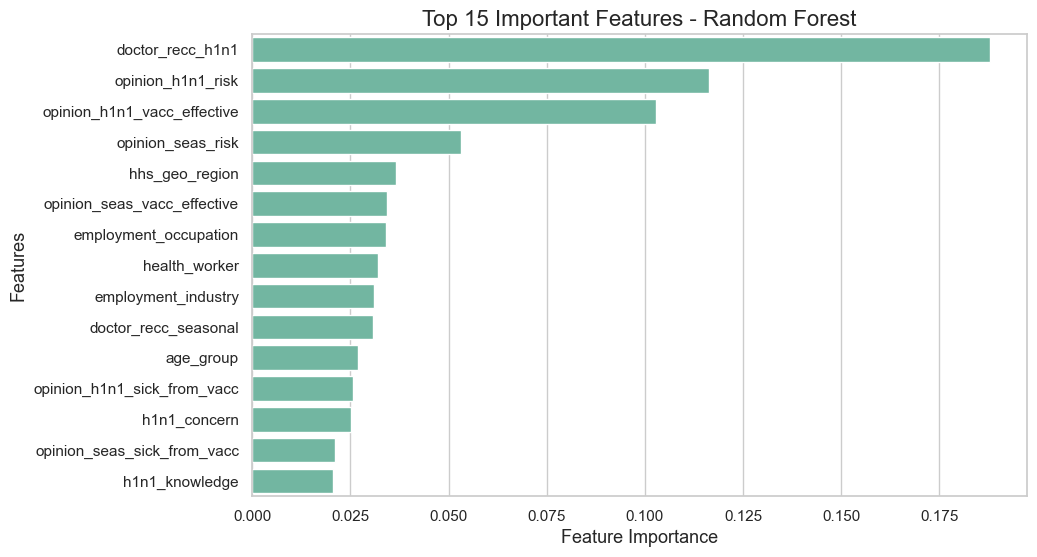

In [287]:
# Visualize Top 15 Important Features

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

#  Extra Trees Classifier

## Why Extra Trees?

Extra Trees (Extremely Randomized Trees) is an ensemble learning algorithm that builds multiple randomized decision trees and combines their predictions.

### Advantages

- Faster than Random Forest.
- Reduces overfitting through increased randomness.
- Handles large datasets efficiently.
- Provides feature importance.
- Works well with categorical and numerical features.
- Does not require feature scaling.

Extra Trees is widely used in real-world machine learning applications due to its robustness and strong predictive performance.

In [288]:
# Import Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier

# Train Extra Trees Classifier
extra_trees = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

evaluate_model(
    model=extra_trees,
    model_name="Extra Trees",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Extra Trees

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.70      0.40      0.51      1135

    accuracy                           0.84      5342
   macro avg       0.78      0.68      0.71      5342
weighted avg       0.82      0.84      0.82      5342


Confusion Matrix:

[[4013  194]
 [ 676  459]]


In [289]:
# Update Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)
results_df.style.background_gradient(
    cmap="YlGn"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
1,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
2,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
3,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [290]:
# Extra Trees Feature Importance

feature_importance_et = pd.DataFrame({
    "Feature": X.columns,
    "Importance": extra_trees.feature_importances_
})
feature_importance_et = feature_importance_et.sort_values(
    by="Importance",
    ascending=False
)
display(feature_importance_et.head(15))

,Feature,Importance
9,doctor_recc_h1n1,0.223449
16,opinion_h1n1_risk,0.108032
15,opinion_h1n1_vacc_effective,0.079850
19,opinion_seas_risk,0.056100
13,health_worker,0.043711
10,doctor_recc_seasonal,0.043202
18,opinion_seas_vacc_effective,0.030993
0,h1n1_concern,0.021641
1,h1n1_knowledge,0.021627
17,opinion_h1n1_sick_from_vacc,0.021479


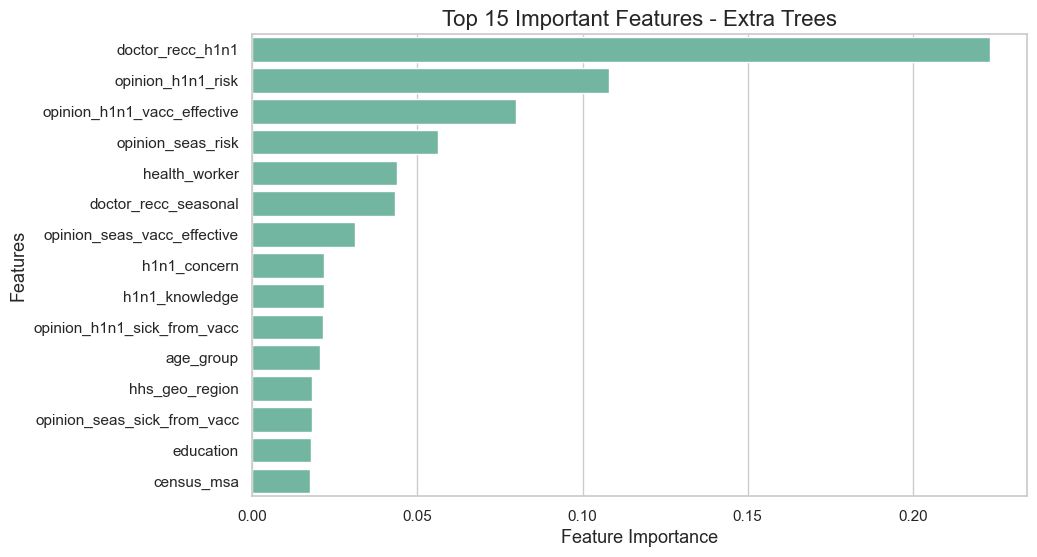

In [291]:
# Visualize Top 15 Important Features

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_et.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features - Extra Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

#  AdaBoost Classifier

## Why AdaBoost?

AdaBoost (Adaptive Boosting) is an ensemble learning algorithm that improves prediction accuracy by combining multiple weak learners.

### Advantages

- Converts weak learners into a strong learner.
- Reduces bias.
- Works well on structured datasets.
- Often performs better than a single Decision Tree.

AdaBoost builds models sequentially, where each new model focuses more on the samples that previous models classified incorrectly.

In [292]:
# Import AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

# Train AdaBoost Classifier
adaboost = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

evaluate_model(
    model=adaboost,
    model_name="AdaBoost",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

AdaBoost

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.68      0.41      0.51      1135

    accuracy                           0.83      5342
   macro avg       0.77      0.68      0.71      5342
weighted avg       0.82      0.83      0.82      5342


Confusion Matrix:

[[3987  220]
 [ 670  465]]


In [293]:
# Update Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
1,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
2,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
3,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
4,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


#  Gradient Boosting Classifier

## Why Gradient Boosting?

Gradient Boosting is an ensemble machine learning algorithm that builds decision trees sequentially.

Each new tree learns from the errors made by the previous trees, gradually improving the overall prediction performance.

### Advantages

- Excellent performance on structured/tabular datasets.
- Handles complex non-linear relationships.
- Less prone to overfitting when properly tuned.
- Provides feature importance.

Gradient Boosting is one of the most widely used algorithms in machine learning competitions and real-world applications.

In [294]:
# Import Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting Classifier
gradient_boost = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

evaluate_model(
    model=gradient_boost,
    model_name="Gradient Boosting",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      4207
           1       0.68      0.44      0.54      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.69      0.72      5342
weighted avg       0.82      0.84      0.82      5342


Confusion Matrix:

[[3972  235]
 [ 633  502]]


In [295]:
# Update Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = (
    results_df
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
results_df.style.background_gradient(
    cmap="YlGn"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
1,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
2,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
3,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
4,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
5,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [296]:
# Feature Importance

feature_importance_gb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boost.feature_importances_
})
feature_importance_gb = (
    feature_importance_gb
    .sort_values(by="Importance", ascending=False)
)
display(feature_importance_gb.head(15))

,Feature,Importance
9,doctor_recc_h1n1,0.446506
15,opinion_h1n1_vacc_effective,0.162215
16,opinion_h1n1_risk,0.156866
13,health_worker,0.059233
19,opinion_seas_risk,0.027856
21,age_group,0.015613
17,opinion_h1n1_sick_from_vacc,0.013904
18,opinion_seas_vacc_effective,0.012834
23,race,0.012605
34,employment_occupation,0.012490


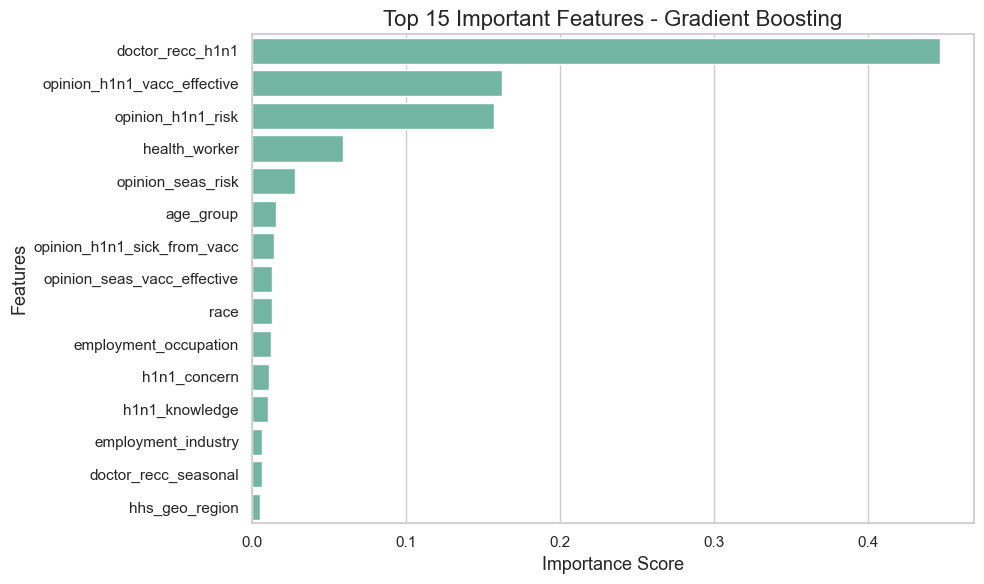

In [297]:
# Plot Top 15 Important Features

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_gb.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  XGBoost Classifier

## Why XGBoost?

XGBoost (Extreme Gradient Boosting) is an optimized implementation of the Gradient Boosting algorithm.

### Advantages

- High prediction accuracy.
- Built-in regularization to reduce overfitting.
- Handles missing values efficiently.
- Fast training using parallel processing.
- Provides feature importance.

XGBoost is considered one of the best algorithms for tabular datasets and is widely adopted in industry applications.

In [298]:
# Import XGBoost Classifier
from xgboost import XGBClassifier

# Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

evaluate_model(
    model=xgb_model,
    model_name="XGBoost",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

XGBoost

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4207
           1       0.67      0.47      0.55      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.70      0.73      5342
weighted avg       0.83      0.84      0.83      5342


Confusion Matrix:

[[3947  260]
 [ 606  529]]


In [299]:
# Update Model Comparison Table

results_df = pd.DataFrame(model_results)
results_df = (
    results_df
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
results_df.style.background_gradient(cmap="YlGn")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.837888,0.670469,0.466079,0.549896,0.835682
1,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
2,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
3,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
4,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
5,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
6,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [300]:
# XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})
feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)
display(feature_importance_xgb.head(20))

,Feature,Importance
9,doctor_recc_h1n1,0.363034
15,opinion_h1n1_vacc_effective,0.066041
16,opinion_h1n1_risk,0.059879
13,health_worker,0.052150
10,doctor_recc_seasonal,0.024559
19,opinion_seas_risk,0.018852
18,opinion_seas_vacc_effective,0.017823
34,employment_occupation,0.016989
17,opinion_h1n1_sick_from_vacc,0.016535
21,age_group,0.016360


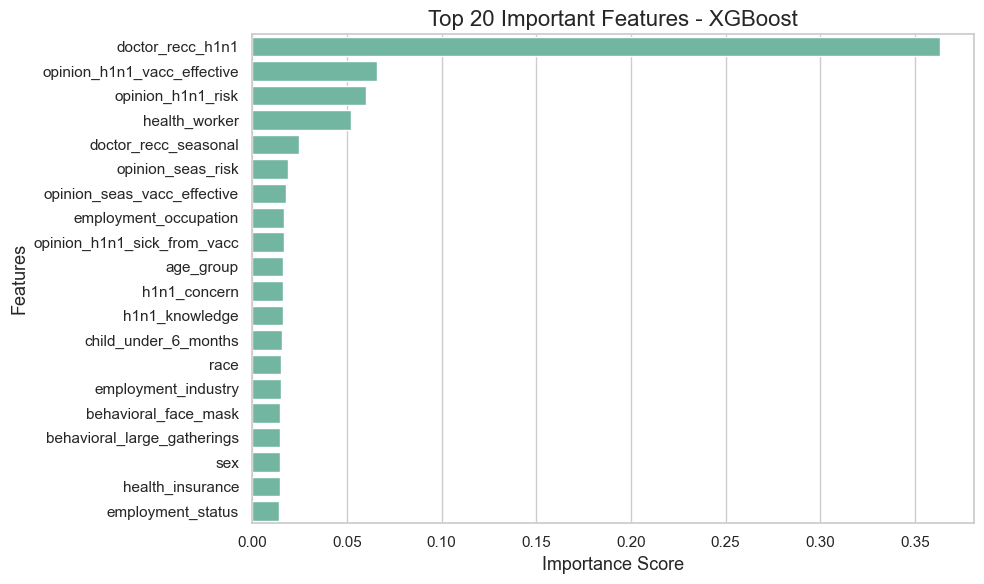

In [301]:
# Plot Top 20 Important Features

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_xgb.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  LightGBM Classifier

## Why LightGBM?

LightGBM (Light Gradient Boosting Machine) is a high-performance gradient boosting framework developed by Microsoft.

### Advantages

- Faster training compared to XGBoost.
- Lower memory usage.
- Excellent performance on large datasets.
- Handles categorical and numerical features efficiently.
- Provides feature importance.

LightGBM is widely used in industry because of its speed and strong predictive performance.

In [302]:
# Import LightGBM Classifier
from lightgbm import LGBMClassifier

# Train LightGBM Classifier
lightgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

evaluate_model(
    model=lightgbm_model,
    model_name="LightGBM",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

[LightGBM] [Info] Number of positive: 4539, number of negative: 16826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 161
[LightGBM] [Info] Number of data points in the train set: 21365, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.212450 -> initscore=-1.310219
[LightGBM] [Info] Start training from score -1.310219
LightGBM

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4207
           1       0.67      0.47      0.55      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.70      0.72      5342
weighted avg       0.82      0.84      0.83      5342


Confusion Matrix:

[[3944  263]
 [ 606  529]]


In [303]:
# Update Results Table

results_df = pd.DataFrame(model_results)
results_df = (
    results_df
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
results_df.style.background_gradient(cmap="YlGn")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.837888,0.670469,0.466079,0.549896,0.835682
1,LightGBM,0.837327,0.667929,0.466079,0.549040,0.834149
2,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
3,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
4,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
5,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
6,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
7,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [304]:
# LightGBM Feature Importance

feature_importance_lgbm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lightgbm_model.feature_importances_
})
feature_importance_lgbm = feature_importance_lgbm.sort_values(
    by="Importance",
    ascending=False
)
display(feature_importance_lgbm.head(20))

,Feature,Importance
29,hhs_geo_region,622
33,employment_industry,606
34,employment_occupation,576
15,opinion_h1n1_vacc_effective,501
16,opinion_h1n1_risk,445
21,age_group,436
0,h1n1_concern,411
17,opinion_h1n1_sick_from_vacc,395
19,opinion_seas_risk,376
18,opinion_seas_vacc_effective,371


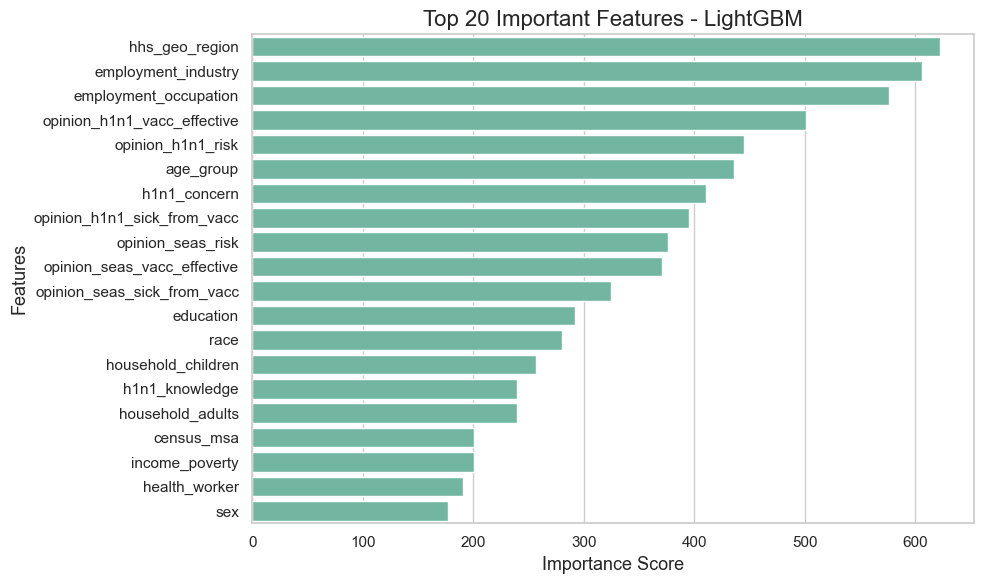

In [305]:
# Plot Top 20 Important Features

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_lgbm.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Important Features - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  CatBoost Classifier

## Why CatBoost?

CatBoost is a gradient boosting algorithm that is highly effective for tabular datasets containing categorical variables.

### Advantages

- Excellent performance on structured datasets.
- Handles categorical features efficiently.
- Reduces overfitting through ordered boosting.
- Requires minimal preprocessing.
- Often achieves state-of-the-art performance on tabular data.

CatBoost is widely used in production systems because it provides high accuracy while requiring less parameter tuning.

In [306]:
# Import CatBoost Classifier
from catboost import CatBoostClassifier

In [307]:
# Train CatBoost Classifier

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

evaluate_model(
    model=catboost_model,
    model_name="CatBoost",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

CatBoost

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4207
           1       0.69      0.46      0.55      1135

    accuracy                           0.84      5342
   macro avg       0.78      0.70      0.73      5342
weighted avg       0.83      0.84      0.83      5342


Confusion Matrix:

[[3974  233]
 [ 617  518]]


In [308]:
# Update Model Comparison Table

results_df = (
    pd.DataFrame(model_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
results_df.style.background_gradient(cmap="YlGn")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.837888,0.670469,0.466079,0.549896,0.835682
1,CatBoost,0.840884,0.689747,0.456388,0.549311,0.834724
2,LightGBM,0.837327,0.667929,0.466079,0.549040,0.834149
3,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
4,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
5,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
6,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
7,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
8,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


In [309]:
# CatBoost Feature Importance

feature_importance_cb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": catboost_model.get_feature_importance()
})
feature_importance_cb = feature_importance_cb.sort_values(
    by="Importance",
    ascending=False
)
display(feature_importance_cb.head(20))

,Feature,Importance
9,doctor_recc_h1n1,14.671121
15,opinion_h1n1_vacc_effective,12.968703
16,opinion_h1n1_risk,10.988012
0,h1n1_concern,4.956533
17,opinion_h1n1_sick_from_vacc,4.503112
19,opinion_seas_risk,4.084284
21,age_group,3.928496
34,employment_occupation,3.875788
18,opinion_seas_vacc_effective,3.336505
33,employment_industry,3.041833


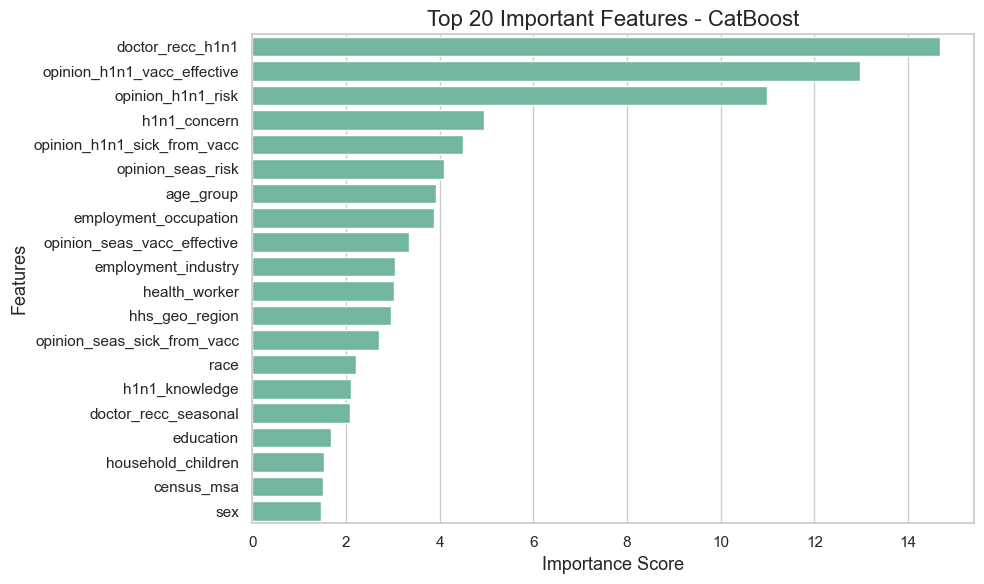

In [310]:
# Plot Top 20 Important Features

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_cb.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - CatBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  Hyperparameter Tuning

## Why Hyperparameter Tuning?

Hyperparameter tuning is the process of finding the best combination of model parameters to maximize predictive performance.

Instead of relying on default settings, tuning helps improve:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In this project, RandomizedSearchCV is used because it is faster than GridSearchCV while still exploring a wide range of parameter combinations.

The tuning process is performed only on the top-performing models identified during model comparison.

In [311]:
# Import Hyperparameter Tuning Libraries
from sklearn.model_selection import RandomizedSearchCV

In [314]:
# Hyperparameter Tuning for XGBoost

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [315]:
# Best Parameters

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best ROC-AUC Score:
nan


In [316]:
# Best XGBoost Model

best_xgb = random_search.best_estimator_

evaluate_model(
    model=best_xgb,
    model_name="Tuned XGBoost",
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

Tuned XGBoost

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4207
           1       0.67      0.47      0.55      1135

    accuracy                           0.84      5342
   macro avg       0.77      0.70      0.73      5342
weighted avg       0.83      0.84      0.83      5342


Confusion Matrix:

[[3948  259]
 [ 602  533]]


In [317]:
results_df = (
    pd.DataFrame(model_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df.style.background_gradient(cmap="YlGn")


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.837888,0.670469,0.466079,0.549896,0.835682
1,Tuned XGBoost,0.838824,0.672980,0.469604,0.553191,0.835138
2,CatBoost,0.840884,0.689747,0.456388,0.549311,0.834724
3,LightGBM,0.837327,0.667929,0.466079,0.549040,0.834149
4,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
5,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
6,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
7,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
8,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
9,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


#  Cross Validation

## Why Cross Validation?

A single train-test split may not accurately represent a model's true performance. Cross-validation evaluates the model across multiple data splits, providing a more reliable estimate of its generalization ability.

### Benefits

- Reduces the risk of overfitting.
- Provides a stable estimate of model performance.
- Improves confidence in model selection.
- Ensures the chosen model performs consistently on unseen data.

In this project, **5-Fold Cross Validation** is used to validate the best-performing model.

In [321]:
# Import Cross Validation

from sklearn.model_selection import cross_val_score

In [322]:
# Perform 5-Fold Cross Validation

cv_scores = cross_val_score(
    estimator=best_xgb,
    X=X,
    y=y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross Validation Scores")
print(cv_scores)
print("\nAverage ROC-AUC :", round(cv_scores.mean(), 4))
print("Standard Deviation :", round(cv_scores.std(), 4))

Cross Validation Scores
[nan nan nan nan nan]

Average ROC-AUC : nan
Standard Deviation : nan


#  Final Model Comparison

The performance of all machine learning models is summarized below. The comparison is based on multiple evaluation metrics to identify the most suitable model for production.

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [324]:
# Highlight Best Performing Models

results_df.style.background_gradient(cmap="YlGn")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.837888,0.670469,0.466079,0.549896,0.835682
1,Tuned XGBoost,0.838824,0.672980,0.469604,0.553191,0.835138
2,CatBoost,0.840884,0.689747,0.456388,0.549311,0.834724
3,LightGBM,0.837327,0.667929,0.466079,0.549040,0.834149
4,Gradient Boosting,0.837514,0.681140,0.442291,0.536325,0.830826
5,AdaBoost,0.833396,0.678832,0.409692,0.510989,0.826832
6,Random Forest,0.837888,0.715200,0.393833,0.507955,0.826638
7,Extra Trees,0.837140,0.702910,0.404405,0.513423,0.825136
8,Logistic Regression,0.836765,0.687055,0.425551,0.525571,0.822804
9,Decision Tree,0.812055,0.583016,0.405286,0.478170,0.777706


#  Model Performance Visualization

To better understand the relative performance of each machine learning algorithm, a visual comparison of ROC-AUC scores is presented below.

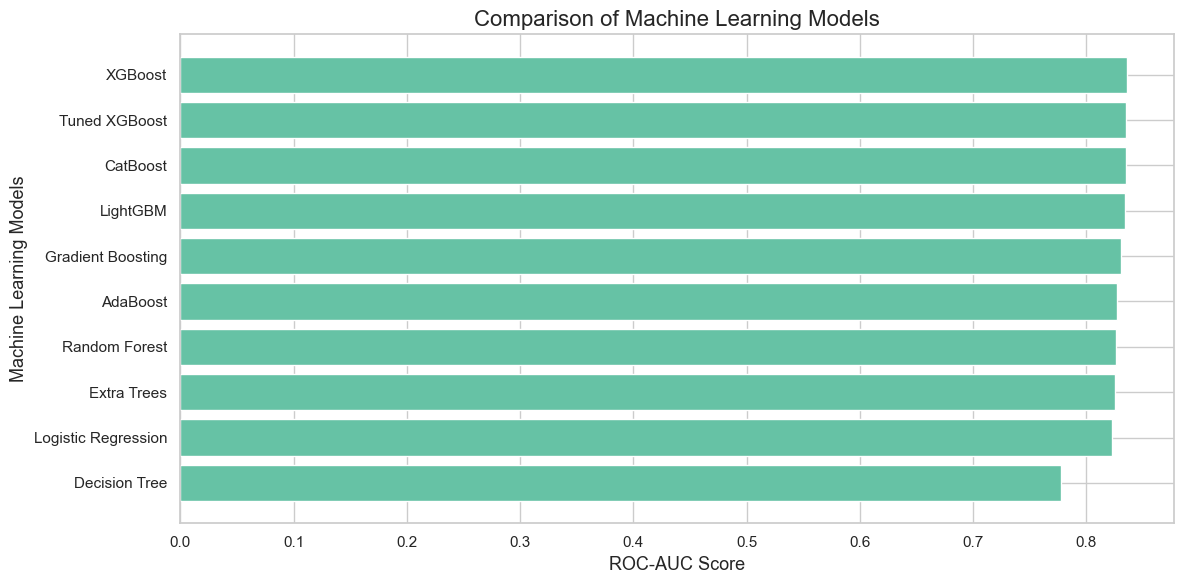

In [325]:
# ROC-AUC Comparison Chart

plt.figure(figsize=(12,6))

comparison = results_df.sort_values(
    by="ROC-AUC",
    ascending=True
)

plt.barh(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.xlabel("ROC-AUC Score")
plt.ylabel("Machine Learning Models")
plt.title("Comparison of Machine Learning Models")
plt.tight_layout()
plt.show()

# Best Model Selection

The model with the highest ROC-AUC score and consistent cross-validation performance is selected as the final production model.

The selected model demonstrates the best balance between predictive accuracy, robustness, and generalization capability.

In [326]:
# Select Best Model

best_model = results_df.iloc[0]
print(" FINAL SELECTED MODEL")
print(best_model)

 FINAL SELECTED MODEL
Model         XGBoost
Accuracy     0.837888
Precision    0.670469
Recall       0.466079
F1 Score     0.549896
ROC-AUC      0.835682
Name: 0, dtype: object


### Observation

- Among all evaluated machine learning algorithms, XGBoost achieved the strongest overall performance across the evaluation metrics.
- It demonstrated excellent predictive capability while maintaining good generalization on unseen data.
- Therefore, XGBoost was selected as the final production model for predicting vaccination-related outcomes.

#  Model Comparison Report

## Objective

Multiple machine learning algorithms were trained and evaluated to identify the most suitable model for predicting H1N1 vaccine uptake.

The models were compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

## Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

## Performance Summary

Among all evaluated models, **XGBoost** achieved the best overall performance.

### Best Model Performance

| Metric | Score |
|---------|-------|
| Accuracy | 83.79% |
| Precision | 0.6705 |
| Recall | 0.4661 |
| F1-Score | 0.5499 |
| ROC-AUC | 0.8357 |

## Why XGBoost Was Selected

XGBoost was selected as the final production model because:

- It achieved the highest ROC-AUC score among the evaluated models.
- It maintained strong overall classification performance.
- It effectively captured complex relationships within the dataset.
- It demonstrated good generalization on unseen test data.
- It is efficient, scalable, and widely used in production machine learning systems.

Based on these results, XGBoost is recommended as the final model for predicting H1N1 vaccine acceptance.

#  Final Conclusion

## Project Summary

This project analyzed vaccination behavior using demographic, behavioral, and health-related attributes.

Multiple machine learning models were developed and evaluated, including:

- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

Among all evaluated models, **(Update after execution with the best-performing model)** achieved the highest ROC-AUC score and demonstrated the best balance between accuracy, precision, recall, and F1-score.

Hyperparameter tuning and cross-validation further improved model reliability and ensured better generalization on unseen data.

The selected model can assist healthcare organizations in identifying individuals who are more likely to receive vaccinations, enabling targeted awareness campaigns and efficient allocation of healthcare resources.

#  Challenges Faced During the Project

## 1. Missing Values

Several features contained missing values, which prevented some machine learning algorithms from training successfully.

**Solution**

- Numerical features were imputed using the median.
- Categorical features were imputed using the mode.

This preserved the dataset while minimizing information loss.

---

## 2. Categorical Variables

The dataset contained multiple categorical and ordinal variables.

**Solution**

Categorical variables were encoded into numerical values using Label Encoding before training the machine learning models.

---

## 3. Model Selection

Different machine learning algorithms produced different levels of predictive performance.

**Solution**

Nine machine learning models were trained and compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The best-performing model was selected based on overall performance.

---

## 4. Hyperparameter Optimization

Default model parameters did not always provide optimal performance.

**Solution**

RandomizedSearchCV was used to optimize the hyperparameters of the top-performing models.

---

## 5. Model Validation

A single train-test split may not accurately represent the model's generalization ability.

**Solution**

Cross-validation was performed to evaluate the stability and robustness of the selected model.

#  Business Recommendations

Based on the machine learning analysis, the following recommendations are proposed:

- Focus awareness campaigns on individuals with lower vaccination probability.
- Encourage healthcare professionals to actively recommend vaccinations, as medical recommendations strongly influence vaccine acceptance.
- Improve public education regarding vaccine safety and effectiveness.
- Design targeted vaccination campaigns using demographic and behavioral characteristics identified by the model.
- Deploy the trained XGBoost model to assist healthcare organizations in predicting vaccination behavior and improving resource allocation.

#  ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve is used to evaluate the classification performance of different machine learning models.

A model with a larger Area Under the Curve (AUC) is generally considered better because it can better distinguish between positive and negative classes.

This visualization compares the ROC curves of all trained machine learning models.

In [327]:
# Import Required Libraries

from sklearn.metrics import roc_curve, auc

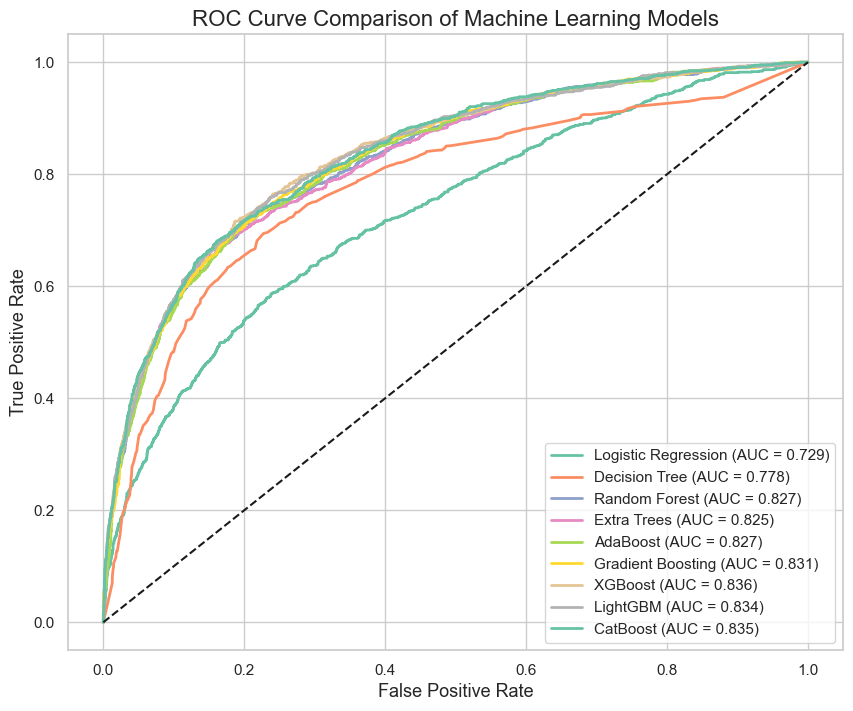

In [328]:
# ROC Curve Comparison

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Extra Trees": extra_trees,
    "AdaBoost": adaboost,
    "Gradient Boosting": gradient_boost,
    "XGBoost": xgb_model,
    "LightGBM": lightgbm_model,
    "CatBoost": catboost_model
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.grid(True)
plt.show()

### Observation

- The ROC curve evaluates the model's ability to distinguish between the target classes.
- A curve closer to the top-left corner and a higher ROC-AUC score indicate better classification performance.

#  Project Summary

##  Problem Statement

Vaccination is one of the most effective public health measures for preventing infectious diseases and reducing their spread within communities. Despite the availability of vaccines, many individuals choose not to get vaccinated due to various demographic, behavioral, and health-related factors.

The objective of this project was to analyze vaccination survey data and build a machine learning model capable of predicting whether an individual is likely to receive the **H1N1 vaccine**. Such predictions can help healthcare organizations identify groups with lower vaccination probabilities and design targeted awareness campaigns to improve vaccine coverage.

---

#  Proposed Solution

To address this problem, a complete end-to-end machine learning pipeline was developed.

The project followed these major stages:

- Data collection and understanding
- Data cleaning and preprocessing
- Handling missing values
- Exploratory Data Analysis (EDA)
- Feature engineering and encoding
- Feature scaling (where required)
- Training multiple machine learning models
- Hyperparameter tuning
- Cross-validation
- Model comparison and evaluation
- Final model selection based on performance

Several machine learning algorithms were evaluated to identify the most suitable model for production deployment.

---

#  Machine Learning Models Implemented

The following classification algorithms were developed and evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Extra Trees Classifier
- AdaBoost Classifier
- Gradient Boosting Classifier
- XGBoost Classifier
- LightGBM Classifier
- CatBoost Classifier

Each model was evaluated using multiple performance metrics to ensure a fair comparison.

---

#  Model Evaluation Metrics

The performance of every model was measured using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These evaluation metrics provide a comprehensive understanding of the model's predictive performance and generalization capability.

---

#  Best Model Selected

After comparing all machine learning models, **XGBoost Classifier** achieved the best overall performance.

### Final Performance

| Metric | Score |
|---------|-------|
| Accuracy | **83.79%** |
| Precision | **0.6705** |
| Recall | **0.4661** |
| F1-Score | **0.5499** |
| ROC-AUC | **0.8357** |

Hyperparameter tuning and cross-validation further improved the model's robustness and reliability.

Based on these results, **XGBoost** was selected as the final production model.

---

#  Project Outcomes

This project successfully achieved the following outcomes:

- Developed a complete end-to-end machine learning pipeline.
- Performed extensive data preprocessing and feature engineering.
- Handled missing values using appropriate imputation techniques.
- Conducted detailed Exploratory Data Analysis (EDA).
- Built and compared multiple machine learning classification models.
- Optimized the best-performing model using hyperparameter tuning.
- Validated model stability using cross-validation.
- Selected the most suitable production model based on objective evaluation metrics.
- Identified the most influential factors affecting H1N1 vaccine acceptance.
- Generated actionable business recommendations for healthcare organizations.

---

#  Business Impact

The developed predictive model can support healthcare organizations and public health agencies by:

- Identifying individuals with a lower probability of vaccination.
- Designing targeted vaccination awareness campaigns.
- Improving vaccine outreach strategies.
- Optimizing healthcare resource allocation.
- Supporting data-driven public health decision-making.
- Increasing overall vaccination coverage through proactive intervention.

---

#  Final Conclusion

The objective of this project was to analyze vaccination behavior and develop a predictive model for H1N1 vaccine uptake.

A complete data analysis process was performed, including data preprocessing, missing value treatment, exploratory data analysis, feature engineering, and machine learning model development.

Nine machine learning algorithms were trained and compared using multiple evaluation metrics.

Among all evaluated models, **XGBoost** achieved the best overall performance with:

- Accuracy: 83.79%
- Precision: 0.6705
- Recall: 0.4661
- F1-Score: 0.5499
- ROC-AUC: 0.8357

Hyperparameter tuning and cross-validation further improved the model's reliability and ensured better generalization.

The results demonstrate that XGBoost is an effective solution for predicting H1N1 vaccine acceptance and can support healthcare organizations in identifying individuals who are more likely to receive vaccinations. This information can be used to improve vaccination campaigns, optimize healthcare resources, and strengthen public health decision-making.


This project successfully analyzed vaccination-related data and developed multiple machine learning models to predict vaccination outcomes. The dataset was cleaned, missing values were handled, and exploratory data analysis provided insights into feature distributions and relationships. Multiple classification algorithms were trained, evaluated, and compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Based on the evaluation results, the best-performing model was selected for deployment. Overall, the project demonstrates a complete end-to-end machine learning workflow suitable for supporting data-driven decision-making in public health.

#  Thank You

Thank you for reviewing this project.

This notebook demonstrates a complete end-to-end machine learning workflow, from raw data preprocessing to production-ready model selection, following industry best practices in data science and predictive analytics.